---
# Data Poisoning in Email Spam Classification: Final Team Project Write-Up
**Course:** GRAD 50400  
**Team:** Group 9  
**Team Members:**

* Garv Jhangiani - 039761425
* Bahram Afsharipoor - 039543049
* Ashish Kumar - 039704863

**Public code repository used for this project:** https://github.com/ajhags17/email-spam-poisoning

---

# Step 1: Problem Definition
**Task Lead:** Ashish Kumar | Bahram Afsharipoor | Garv Jhangiani
### Problem Statement


In this project, we aim to investigate how data poisoning attacks can compromise machine learning based email spam classifiers trained on standard benchmark datasets. Data poisoning attacks occur when an adversary injects or relabels a small fraction of training examples so that the learned model systematically misclassifies future inputs, such as treating spam messages as legitimate email. Prior work has shown that supervised models like Support Vector Machines (SVMs) can suffer large increases in test error under optimized poisoning points, even when the attacker controls only a modest portion of the training set. Building on these ideas, our project focuses on supervised spam/ham classification using publicly available datasets and explores how different poisoning strategies (e.g., label flipping on structured features, text‑based poisoning on raw emails) affect filter performance and robustness.




### Why this problem matters

Email remains a primary communication channel for both individuals and organizations, and spam filtering is a critical security layer that helps block phishing, fraud, and malware campaigns. Large email corpora such as the Enron Corpus and widely used spam benchmarks demonstrate that statistical and machine learning based filters are standard practice for separating spam from legitimate messages at scale. However, as training data increasingly comes from semi‑automated or user driven sources (for example, users marking messages as “spam” or “not spam”), the assumption that training data is trustworthy becomes unrealistic, opening the door to adversaries who can poison the training pipeline. Research on poisoning attacks and certified defenses has shown that even small poisoning budgets can substantially degrade classifier performance on text datasets, highlighting a concrete security risk for spam filters deployed in the wild. Understanding these vulnerabilities in the specific context of email spam classification is therefore important for improving email security, maintaining user trust, and informing the design of more robust training procedures.


### Application feasibility and data context

Publicly available datasets make it feasible to study data poisoning in spam classification without collecting sensitive user data. The Spambase dataset from the UCI Machine Learning Repository provides pre‑extracted numerical features (e.g., word and character frequencies, capitalization statistics) along with spam/ham labels at the email level, offering a structured benchmark for label flipping and feature space poisoning attacks. The Kaggle Spam Email Dataset contains raw email text with spam/ham labels in a tabular CSV format, which supports realistic text based preprocessing, feature extraction, and poisoning experiments on full email bodies. The SpamAssassin Public Corpus provides real world email messages originally distributed as raw mail files, which can be converted into a CSV with body text and labels inferred from folder structure, enabling experiments in a more realistic email environment. Because all three datasets are public, well documented, and commonly used in research, they can be processed using standard Python tools and integrated into a coherent experimental pipeline, as described in Step 2’s data identification and exploration.

### Scope and constraints

The scope of this project is limited to offline, training time data poisoning attacks against supervised binary classifiers that distinguish spam from ham. We focus on learning algorithms such as logistic regression and SVMs applied to (1) structured feature vectors from Spambase and (2) text representations (e.g., bag‑of‑words or embeddings) derived from the Kaggle and SpamAssassin datasets. Our threat model assumes an attacker who knows the learning algorithm and can inject or relabel a limited fraction of training emails but cannot modify the test distribution or the model architecture once deployed, consistent with prior poisoning work on SVMs and text classification. We restrict attention to attacks that aim to increase overall misclassification rates or the proportion of spam that is misclassified as ham, rather than highly targeted attacks on specific individual messages. We do not attempt to design new certified defenses; instead, we use existing theoretical results on certified defenses primarily as motivation and consider only basic defensive baselines such as simple data sanitization for empirical comparison.

### Success evaluation criteria

To assess whether our project successfully addresses the research problem, we define three main evaluation criteria as:

#### Baseline performance on clean data

Train baseline spam classifiers on unpoisoned splits of Spambase, Kaggle, and SpamAssassin and report standard metrics (accuracy, precision, recall, F1) on heldout test sets.

Ensure that each baseline achieves reasonable performance consistent with prior spam classification studies, so that poisoning results are measured against competent models rather than poorly performing baselines.

#### Impact of poisoning under controlled budgets

Implement poisoning strategies inspired by prior work on SVM poisoning and label flipping (e.g., relabeling a small fraction of structured Spambase points, injecting adversarially chosen text emails into Kaggle and SpamAssassin training sets) and vary the poisoning budget (e.g., 1–10% of training data).

Measure how key performance metrics degrade as the poisoning budget increases, with particular attention to increases in spam-as-ham misclassification rates, analogous to the error inflation reported in earlier poisoning studies.

#### Preliminary robustness and defense observations

Evaluate simple defensive baselines, such as removing outlier points in feature space, filtering suspicious training emails, or using more robust loss functions, and compare poisoned performance with and without these defenses on each dataset.

Qualitatively relate the empirical trends we observe (e.g., which datasets or models are more resilient to naive defenses) to insights from the certified defense literature, even though providing formal robustness guarantees is beyond our current scope.

---
# Step 2: Data Identification and Exploration
**Task Lead:** Ashish Kumar | Bahram Afsharipoor | Garv Jhangiani
## Data Source Identification

### A. Spambase Dataset (Structured Email Features)
- **Source:** UCI Machine Learning Repository
- **Original File:** `spambase.data`
- **Working File Used in Analysis:** `spambase.csv`
- **Content:** Pre-extracted numerical features from emails, such as word frequencies, character frequencies, and capital letter statistics
- **Granularity:** Individual email level
- **URL:** https://archive.ics.uci.edu/dataset/94/spambase

### B. Spam Email Dataset (Text-Based)
- **Source:** Kaggle
- **File:** `emails.csv`
- **Content:** Email text with spam/ham labels
- **Granularity:** Individual email level
- **URL:** https://www.kaggle.com/datasets/jackksoncsie/spam-email-dataset

### C. SpamAssassin Dataset (Real-World Emails)
- **Source:** Apache SpamAssassin Public Corpus
- **Original Format:** Raw email files stored in folders
- **Working File Used in Analysis:** `spamassassin.csv`
- **Content:** Real email messages labeled as spam and non-spam
- **Granularity:** Individual email level
- **URL:** https://spamassassin.apache.org/old/publiccorpus/

## Data Availability and Ethical Considerations

All three datasets are publicly available and suitable for academic analysis.

- The **Spambase** dataset was originally distributed as a `.data` file, not as a ready-to-use CSV. We converted it into CSV format by assigning column names and saving the structured output as `spambase.csv`.
- The **SpamAssassin** corpus was originally distributed as raw email files rather than a tabular dataset. We parsed the email files, extracted the email body text, assigned labels based on folder category, and saved the result as `spamassassin.csv`.
- The **Kaggle Spam Email Dataset** was already available as a CSV file.

These preprocessing steps were necessary to standardize the datasets into a format suitable for exploration, modeling, and later poisoning experiments.

The datasets do not contain private user information collected by our team, and they are commonly used for research and educational purposes. One limitation is that some datasets are older and may not fully represent modern spam patterns. In addition, the three datasets differ in format: Spambase contains engineered numeric features, while the Kaggle and SpamAssassin datasets contain raw text.

## Data Exploration and Quality Assessment

To evaluate the suitability of our identified datasets, we conduct a preliminary exploration of each source.

## Data Loading

This notebook supports both:
- Local execution (CSV files in same directory)
- Remote execution via GitHub raw links

This ensures reproducibility across environments.

In [1]:
# Required libraries:
# pandas, numpy, matplotlib, seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Optional display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

# Paths
local_path = "./"
github_url = "https://raw.githubusercontent.com/ajhags17/email-spam-poisoning/main/"

# Hybrid loader (works locally + GitHub)
def load_file(filename):
    if os.path.exists(local_path + filename):
        print(f"Loading {filename} from local")
        return pd.read_csv(local_path + filename)
    else:
        print(f"Loading {filename} from GitHub")
        return pd.read_csv(github_url + filename)

# Load datasets
spambase_df = load_file("spambase.csv")
kaggle_df = load_file("spamemails.csv")
spamassassin_df = load_file("spamassassin.csv")

print("Datasets loaded successfully")

Loading spambase.csv from local
Loading spamemails.csv from local
Loading spamassassin.csv from local
Datasets loaded successfully


## Dataset 1: Spambase Data Quality Assessment

The Spambase dataset contains pre-extracted numerical features rather than raw email text. This makes it useful for structured modeling and for evaluating label-flipping attacks, although it does not allow direct text-level manipulation.

=== SPAMBASE DATA EXPLORATION ===
Dataset shape: (4601, 58)

First 10 columns: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail']

Label column detected: spam
Total missing values: 0
Duplicate rows: 391

Label distribution:
spam
0    2788
1    1813
Name: count, dtype: int64

Label percentages:
spam
0    60.6
1    39.4
Name: proportion, dtype: float64

Summary statistics for a sample of numeric features:
       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count     4601.000000        4601.000000    4601.000000   4601.000000   
mean         0.104553           0.213015       0.280656      0.065425   
std          0.305358           1.290575       0.504143      1.395151   
min          0.000000           0.000000       0.000000      0.000000   
25%          0.000000           0.000000       0.000000      0.000000   
50%          0.0000

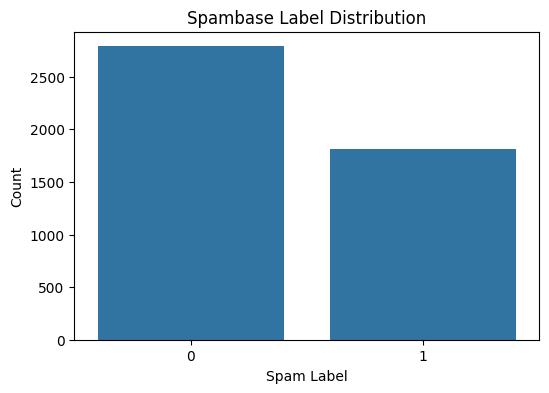


Spambase appears suitable for structured spam classification and label-flipping experiments.


In [2]:
if spambase_df is not None:
    print("=== SPAMBASE DATA EXPLORATION ===")
    print(f"Dataset shape: {spambase_df.shape}")
    print(f"\nFirst 10 columns: {list(spambase_df.columns[:10])}")

    # Check whether label column exists
    label_col = "spam" if "spam" in spambase_df.columns else "label" if "label" in spambase_df.columns else None
    print(f"\nLabel column detected: {label_col}")

    # Missing values
    total_missing = spambase_df.isnull().sum().sum()
    print(f"Total missing values: {total_missing}")

    # Duplicate rows
    duplicate_rows = spambase_df.duplicated().sum()
    print(f"Duplicate rows: {duplicate_rows}")

    # Label distribution
    if label_col:
        print("\nLabel distribution:")
        print(spambase_df[label_col].value_counts(dropna=False))

        label_percentages = spambase_df[label_col].value_counts(normalize=True) * 100
        print("\nLabel percentages:")
        print(label_percentages.round(2))

    # Numeric summary
    print("\nSummary statistics for a sample of numeric features:")
    print(spambase_df.describe().iloc[:, :10])

    # Check if all feature columns are numeric
    non_numeric_cols = spambase_df.select_dtypes(exclude=[np.number]).columns.tolist()
    print(f"\nNon-numeric columns found: {non_numeric_cols}")

    # Plot class distribution
    if label_col:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=spambase_df[label_col])
        plt.title("Spambase Label Distribution")
        plt.xlabel("Spam Label")
        plt.ylabel("Count")
        plt.show()

    print("\nSpambase appears suitable for structured spam classification and label-flipping experiments.")
else:
    print("Cannot assess Spambase data quality")

## Dataset 2: Kaggle Spam Email Dataset Quality Assessment

The Kaggle dataset contains raw email text and labels, making it appropriate for text-based spam classification. Because our project focuses on poisoning in email spam classification, this dataset is especially useful for realistic preprocessing, feature extraction, and evaluation.

=== KAGGLE EMAIL DATA EXPLORATION ===
Dataset shape: (5728, 2)

Column names: ['text', 'spam']

Text column detected: text
Label column detected: spam

Missing values by column:
text    0
spam    0
dtype: int64

Duplicate rows: 33

Label distribution:
spam
0    4360
1    1368
Name: count, dtype: int64

Label percentages:
spam
0    76.12
1    23.88
Name: proportion, dtype: float64

Text length statistics:
count     5728.000000
mean      1556.768680
std       2042.649812
min         13.000000
25%        508.750000
50%        979.000000
75%       1894.250000
max      43952.000000
Name: text_length, dtype: float64
Empty or blank text rows: 0

Sample records:
                                                                                                                      text  \
0  Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is f...   
1  Subject: the stock trading gunslinger  fanny is merrill but muzo not colza attaind

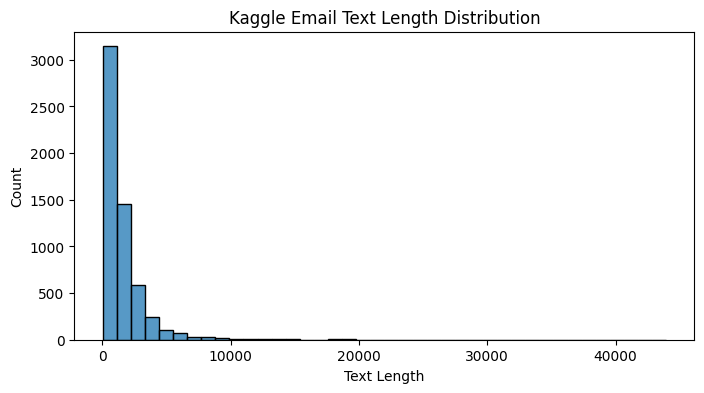

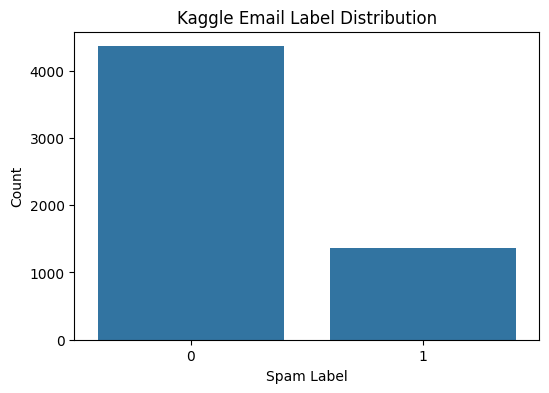


The Kaggle dataset appears suitable for text-based spam classification and poisoning experiments.


In [3]:
if kaggle_df is not None:
    print("=== KAGGLE EMAIL DATA EXPLORATION ===")
    print(f"Dataset shape: {kaggle_df.shape}")
    print(f"\nColumn names: {list(kaggle_df.columns)}")

    # Try to identify text and label columns
    text_col = "text" if "text" in kaggle_df.columns else None
    label_col = "label" if "label" in kaggle_df.columns else "spam" if "spam" in kaggle_df.columns else None

    print(f"\nText column detected: {text_col}")
    print(f"Label column detected: {label_col}")

    # Missing values
    print("\nMissing values by column:")
    print(kaggle_df.isnull().sum())

    # Duplicate rows
    duplicate_rows = kaggle_df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicate_rows}")

    # Label distribution
    if label_col:
        print("\nLabel distribution:")
        print(kaggle_df[label_col].value_counts(dropna=False))

        label_percentages = kaggle_df[label_col].value_counts(normalize=True) * 100
        print("\nLabel percentages:")
        print(label_percentages.round(2))

    # Text length analysis
    if text_col:
        kaggle_df["text_length"] = kaggle_df[text_col].astype(str).apply(len)

        print("\nText length statistics:")
        print(kaggle_df["text_length"].describe())

        empty_like = (kaggle_df[text_col].astype(str).str.strip() == "").sum()
        print(f"Empty or blank text rows: {empty_like}")

        print("\nSample records:")
        print(kaggle_df[[text_col, label_col]].head(3))

        plt.figure(figsize=(8, 4))
        sns.histplot(kaggle_df["text_length"], bins=40, kde=False)
        plt.title("Kaggle Email Text Length Distribution")
        plt.xlabel("Text Length")
        plt.ylabel("Count")
        plt.show()

    if label_col:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=kaggle_df[label_col])
        plt.title("Kaggle Email Label Distribution")
        plt.xlabel("Spam Label")
        plt.ylabel("Count")
        plt.show()

    print("\nThe Kaggle dataset appears suitable for text-based spam classification and poisoning experiments.")
else:
    print("Cannot assess Kaggle email data quality")

## Dataset 3: SpamAssassin Data Quality Assessment

The SpamAssassin dataset contains real-world email messages that were originally distributed as raw email files. We converted these messages into CSV format by extracting the body text and assigning labels based on the original folder categories. This dataset is especially useful because it provides a realistic spam classification setting.

=== SPAMASSASSIN DATA EXPLORATION ===
Dataset shape: (3150, 5)

Column names: ['subject', 'text', 'label', 'source_file', 'source_folder']

Text column detected: text
Label column detected: label

Missing values by column:
subject          5
text             0
label            0
source_file      0
source_folder    0
dtype: int64

Duplicate rows: 0

Label distribution:
label
0    2711
1     439
Name: count, dtype: int64

Label percentages:
label
0    86.06
1    13.94
Name: proportion, dtype: float64

Text length statistics:
count      3150.000000
mean       2959.582222
std        8275.749227
min          44.000000
25%         531.250000
50%        1018.500000
75%        1909.750000
max      202499.000000
Name: text_length, dtype: float64
Empty or blank text rows: 0

Sample records:
                                                                                                                      text  \
0  Date:        Wed, 21 Aug 2002 10:54:46 -0500\n    From:        Chris Garrigues 

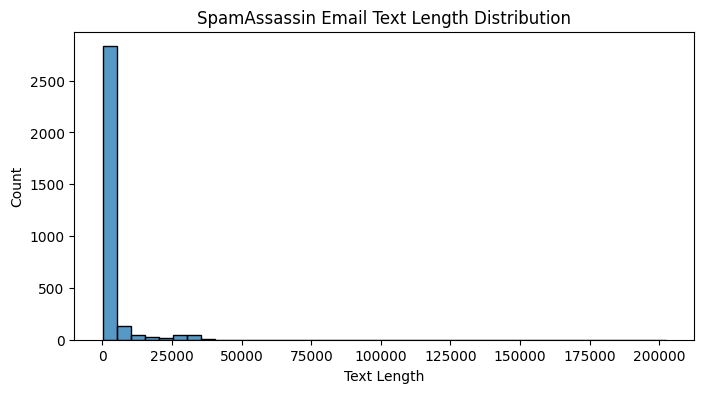

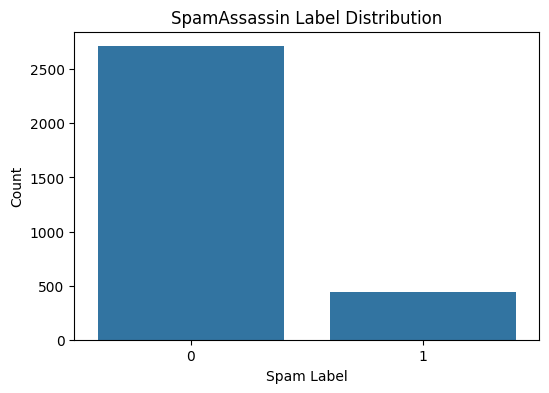


SpamAssassin appears suitable for real-world email spam classification and poisoning experiments.


In [4]:
if spamassassin_df is not None:
    print("=== SPAMASSASSIN DATA EXPLORATION ===")
    print(f"Dataset shape: {spamassassin_df.shape}")
    print(f"\nColumn names: {list(spamassassin_df.columns)}")

    # Try to identify text and label columns
    text_col = "text" if "text" in spamassassin_df.columns else None
    label_col = "label" if "label" in spamassassin_df.columns else "spam" if "spam" in spamassassin_df.columns else None

    print(f"\nText column detected: {text_col}")
    print(f"Label column detected: {label_col}")

    # Missing values
    print("\nMissing values by column:")
    print(spamassassin_df.isnull().sum())

    # Duplicate rows
    duplicate_rows = spamassassin_df.duplicated().sum()
    print(f"\nDuplicate rows: {duplicate_rows}")

    # Label distribution
    if label_col:
        print("\nLabel distribution:")
        print(spamassassin_df[label_col].value_counts(dropna=False))

        label_percentages = spamassassin_df[label_col].value_counts(normalize=True) * 100
        print("\nLabel percentages:")
        print(label_percentages.round(2))

    # Text length analysis
    if text_col:
        spamassassin_df["text_length"] = spamassassin_df[text_col].astype(str).apply(len)

        print("\nText length statistics:")
        print(spamassassin_df["text_length"].describe())

        empty_like = (spamassassin_df[text_col].astype(str).str.strip() == "").sum()
        print(f"Empty or blank text rows: {empty_like}")

        print("\nSample records:")
        if label_col:
            print(spamassassin_df[[text_col, label_col]].head(3))
        else:
            print(spamassassin_df[[text_col]].head(3))

        plt.figure(figsize=(8, 4))
        sns.histplot(spamassassin_df["text_length"], bins=40, kde=False)
        plt.title("SpamAssassin Email Text Length Distribution")
        plt.xlabel("Text Length")
        plt.ylabel("Count")
        plt.show()

    if label_col:
        plt.figure(figsize=(6, 4))
        sns.countplot(x=spamassassin_df[label_col])
        plt.title("SpamAssassin Label Distribution")
        plt.xlabel("Spam Label")
        plt.ylabel("Count")
        plt.show()

    print("\nSpamAssassin appears suitable for real-world email spam classification and poisoning experiments.")
else:
    print("Cannot assess SpamAssassin data quality")

## Dataset Integration Feasibility Check

The three datasets differ in representation:

- **Spambase** contains pre-extracted numerical features
- **Kaggle** and **SpamAssassin** contain raw email text and labels

Because of this, the datasets are not intended to be merged into one single training table directly. Instead, they support the project in complementary ways:

- Spambase supports structured baseline experiments
- Kaggle supports text-based modeling on already-tabular data
- SpamAssassin supports text-based modeling on more realistic email content

For the text-based datasets, we also verify whether they can be standardized into a common structure for later processing and evaluation.

In [5]:
print("=== DATASET INTEGRATION FEASIBILITY CHECK ===")

datasets = {
    "Spambase": spambase_df,
    "Kaggle": kaggle_df,
    "SpamAssassin": spamassassin_df
}

for name, df in datasets.items():
    if df is not None:
        print(f"\n{name} columns:")
        print(list(df.columns))

# Check text/label compatibility for text-based datasets
text_datasets = {
    "Kaggle": kaggle_df,
    "SpamAssassin": spamassassin_df
}

print("\n=== TEXT DATASET COMPATIBILITY CHECK ===")
for name, df in text_datasets.items():
    if df is not None:
        has_text = "text" in df.columns
        has_label = "label" in df.columns or "spam" in df.columns
        print(f"{name}: has_text={has_text}, has_label={has_label}")

print("\nIntegration conclusion:")
print("- Spambase can be used as a separate structured baseline dataset.")
print("- Kaggle and SpamAssassin can be standardized into a similar text + label format.")
print("- Overall, the datasets are suitable for the planned exploratory analysis and later poisoning experiments.")

=== DATASET INTEGRATION FEASIBILITY CHECK ===

Spambase columns:
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(', 'c

# Data Suitability and Project Feasibility
The selected datasets—Spambase (UCI), Kaggle Spam Email Dataset, and SpamAssassin Public Corpus—are well-suited for analyzing the impact of data poisoning in email spam classification. Together, they provide a combination of structured numerical features and raw text data, enabling evaluation of both feature-level and content-based adversarial attacks.
These datasets capture important real-world characteristics such as class imbalance, noisy features, and heterogeneous data representations, which are critical for simulating adversarial conditions in machine learning systems.

## Lightweight Data Exploration Evidence

Preliminary exploration of the datasets reveals:

* The datasets contain several thousand observations each, providing sufficient scale for training and evaluating machine learning models
* The Kaggle dataset exhibits moderate class imbalance, with a higher proportion of legitimate (ham) emails relative to spam
* The Spambase dataset consists entirely of numerical, pre-engineered features, making it well-suited for structured modeling and controlled label-flipping experiments
* The SpamAssassin dataset includes raw email content and headers, enabling richer feature extraction and more realistic simulation of adversarial manipulation
* Initial inspection indicates the presence of duplicate and potentially noisy records, which will be addressed during preprocessing
These observations confirm that the datasets are both diverse and complementary, supporting robust experimentation across multiple data representations.

## Limitations and Mitigation

While the datasets are appropriate for this analysis, several limitations must be addressed:

* **Data Redundancy:** Preliminary exploration identified duplicate records in some datasets, which may bias model training and evaluation

* **Class Imbalance:** The Kaggle dataset is moderately imbalanced (approximately 70–80% ham and 20–30% spam), which may lead to biased predictions

* **Feature Inconsistency:** Spambase uses pre-engineered numerical features, whereas the other datasets consist of raw text requiring transformation

* **Temporal Bias:** The SpamAssassin dataset reflects older spam patterns, which may not fully capture modern attack strategies

* **Generalizability:** Models trained on these datasets may not fully generalize to enterprise-scale or evolving real-world environments

To mitigate these challenges, we will:

* Remove duplicate records and standardize datasets during preprocessing
* Apply stratified sampling and class weighting to address class imbalance
* Use feature transformation techniques such as TF-IDF vectorization for text data
* Implement controlled poisoning strategies (e.g., label flipping and content injection) at varying intensities
* Evaluate models across multiple datasets to reduce dataset-specific bias and improve robustness

## Feasibility of Approach

The project is technically feasible within the course timeline and available computational resources.

* All datasets are publicly accessible, ethically sourced, and appropriate for academic use
* Dataset sizes (several thousand records each) are manageable within environments such as Google Colab
* Standard machine learning models (e.g., Logistic Regression, Naive Bayes, Support Vector Machines) are computationally efficient and well-suited for spam classification tasks
* Data poisoning strategies can be implemented through controlled data manipulation without requiring specialized infrastructure

The project supports multiple modeling and evaluation approaches, enabling systematic comparison of model robustness under adversarial conditions, which aligns with course requirements.



# Summary of Data Suitability

Our preliminary exploration suggests that the selected datasets are suitable for the project.

- **Spambase** is appropriate for structured classification experiments because it already contains engineered features and a spam label.
- **Kaggle Spam Email Dataset** is appropriate for text-based classification because it contains labeled email content in a tabular format.
- **SpamAssassin** is appropriate for real-world validation because it contains authentic email messages that were successfully converted into structured CSV format.

Together, these datasets provide both structured and text-based perspectives on spam classification, which supports our proposed study of label-flipping data poisoning attacks.

---
# Step 3: Model Evaluation Plan

**Task Lead:** Garv Jhangiani  
**Collaborators:** Ashish Kumar | Bahram Afsharipoor

While designing our plan to evaluate model efficacy, we have considered that the evaluation framework should be (a) comparable across datasets and models, and (b) sensitive to poisoning-specific failure models, especially spam being misclassified as ham.

## Evaluation Metrics and Why they are appropriate
We will use the following metrics across all models and datasets:

**Accuracy:** Overall fraction of correctly classified emails (spam and ham). This provides a high‑level view of performance but can be misleading under class imbalance, so it will not be used alone for model selection.

**Precision (spam class):** Among emails predicted as spam, the fraction that are truly spam. High precision reduces false positives (ham flagged as spam), which is important for user experience and trust.

**Recall (spam class):** Among truly spam emails, the fraction correctly flagged as spam. High recall is critical for security because missed spam corresponds to malicious or unwanted emails reaching users.

**F1‑score (spam class):** Harmonic mean of spam precision and recall. This summarizes the trade‑off between blocking spam and avoiding false alarms and will be our primary scalar metric for comparing models on each dataset.

**Spam‑as‑ham misclassification rate (SAH):** The proportion of spam emails misclassified as ham (false negative rate for spam). This is the most security‑relevant quantity under poisoning, because many poisoning strategies explicitly aim to increase SAH so that adversarial spam bypasses the filter.

Where helpful, we may also report ROC‑AUC for the spam class as a threshold‑independent metric, but F1 and SAH will be emphasized in tables and plots.

We will also record training and inference time for each model at each poisoning level to assess computational scalability. This is particularly relevant for SVM models on larger text corpora (Kaggle, SpamAssassin), where kernel computation scales poorly with dataset size and may become a practical bottleneck in deployment.

## Success Criteria
We will be comparing the baseline performance of these models with its robustness against poisoning.

**Baseline performance on clean data**

For each dataset (Spambase, Kaggle, SpamAssassin), a model is considered a reasonable baseline if it achieves “typical” spam‑filter performance reported in prior work (e.g., high F1 and substantially better than a majority‑class baseline).

Practically, we will aim for F1 on the spam class that is competitive with standard linear models (e.g., logistic regression, SVM, Naive Bayes) on these benchmarks, so that poisoning experiments are conducted on competent models rather than poorly tuned baselines.

Robustness under poisoning For each model–dataset combination, we consider robustness with respect to a poisoning budget ϵ defined as the fraction of training points that are modified (label‑flipped or adversarially injected).

A model is considered relatively robust in a given setting if, for poisoning budgets up to a small threshold (e.g., ϵ≤5%), the following hold:

F1 on the spam class does not drop by more than a pre‑specified margin relative to the clean baseline (e.g., ≤ 10 percentage points).

SAH does not grow dramatically (e.g., no more than a modest relative increase for small ϵ).

Conversely, a model is considered vulnerable if modest poisoning budgets (e.g.,ϵ ≤ 5%) cause large F1 degradation or large spikes in SAH, especially when compared across models or datasets.

These success criteria allow us to compare models along two axes: baseline quality and degradation curves under increasing poisoning intensity.

## Evaluation Data and Splits
We will use consistent evaluation protocols across datasets to isolate the effect of poisoning:

**Spambase (structured features)**

We will perform a stratified train/validation/test split (70%/15%/15%) so the spam/ham ratio is preserved in each subset.

Poisoning will be applied only to the training subset; validation and test sets will remain clean to approximate real‑world deployment where attackers cannot modify evaluation data.

All reported metrics (accuracy, precision, recall, F1, SAH) will be computed on the clean test set as functions of the training poisoning budget.

**Kaggle Spam Email Dataset (text)**

We will use a similar stratified train/validation/test split (70%/15%/15%) on the text data with spam labels.

Poisoned emails (content‑modified or injected emails labeled as ham or spam, depending on the attack) will only be introduced into the training set.

The test set will be kept clean to measure how poisoning the training data alone affects generalization.

**SpamAssassin Corpus (text)**

We will split the converted CSV into stratified train/validation/test sets analogous to the Kaggle setup, maintaining the original spam/ham imbalance.

As with the other datasets, poisoning will be restricted to the training split; validation and test remain untouched.

Because SpamAssassin is more realistic and older, we may also perform cross‑dataset evaluation (e.g., train on Kaggle, test on SpamAssassin) as an additional robustness check, time permitting.

For all datasets, hyperparameter tuning (e.g., regularization strength for logistic regression, kernel parameters for SVM) will be performed using the validation set on clean training data. This prevents tuning decisions from being biased by specific poisoning patterns and allows us to isolate the impact of poisoning on a fixed, reasonably tuned model.

## Evaluation Proposals

### Evaluation Proposal 1 – Robustness against Label‑Flipping on Spambase
**Objective:**
Quantify how flipping labels for a small fraction of structured training points affects spam‑filter performance and SAH for different classifiers (e.g., logistic regression, SVM, Naive Bayes) on the Spambase dataset.

**Setup:**

Use the Spambase train/validation/test split described in Section 3.3.

For each poisoning budget ϵ ∈ {0%,1%,3%,5%,10%}, select a subset of training emails and flip their labels according to the chosen attack strategy (e.g., spam → ham, ham → spam).

Train each candidate model on the poisoned training data and evaluate on the clean test set.

**Metrics reported:**

Accuracy, spam precision, spam recall, and spam F1 at each poisoning level.

SAH as a function of
ϵ, highlighting how often spam slips through as ham.

**Why this proposal:**

Spambase provides structured, tabular features and a spam proportion that is closer to balanced than the text corpora, enabling a clean study of label‑noise robustness without confounding text processing issues.

Label‑flipping is a canonical poisoning strategy for supervised learners; robustness curves (F1 vs ϵ, SAH vs ϵ) give a quantitative picture of how quickly each model degrades as more labels are corrupted.

This proposal directly addresses model efficacy under label‑level poisoning and allows clear comparison of algorithms on the same dataset and attack.

### Evaluation Proposal 2 – Robustness to Content‑Injection Poisoning on Text Datasets
**Objective:**
Evaluate how injecting adversarial or modified emails into the training set influences text‑based models’ ability to detect spam, especially for spam styles that resemble the injected content, on Kaggle and SpamAssassin.

**Setup:**

Use the Kaggle and SpamAssassin train/validation/test splits described in Section 3.3.

For each poisoning budget ϵ, inject or modify a subset of training emails by:

Adding spam‑like content but labeling it as ham, or

Modifying existing ham emails with spammy phrases, depending on the attack design.

Train text‑based models (e.g., logistic regression or SVM on TF‑IDF features) on the poisoned training data and evaluate on the clean test sets.

**Metrics reported:**

Accuracy, spam precision, spam recall, and spam F1 on each dataset at each poisoning level.

SAH, with particular attention to emails whose content is similar to the injected or modified examples.

**Why this proposal:**

Real‑world spam filters operate on raw email text; content poisoning is closer to an adversary modifying or injecting emails into training pipelines or user feedback.

Using two separate text corpora with different spam/ham proportions and writing styles allows us to see whether robustness is dataset‑dependent and whether models that look strong on one corpus break on another.

This proposal measures how poisoning changes what spam patterns the model learns to treat as benign, which is central to the threat model for spam data poisoning.


# Evaluation Proposal 3 – Defensive Robustness Evaluation 

This proposal will be executed if implementation timelines from Steps 4 and 5 allow, but is planned as part of the full evaluation framework. 

**Objective:** Assess whether simple defenses (e.g., class‑weighted loss, basic outlier removal, or filtering of suspicious training examples) meaningfully improve robustness to poisoning in the setups defined in Proposals 1 and 2. 

**Setup:** 

Reuse the train/validation/test splits and poisoning budget sweep (ε ∈ {0%, 1%, 3%, 5%, 10%}) from Proposals 1 and 2. 

For each model and poisoning level, train two versions: 

A baseline model with standard training (no defense). 

A defended model with simple mitigation applied, such as class weighting to counteract spam/ham imbalance, removal of high‑loss training points suspected of being poisoned, or filtering of training examples that are outliers in feature space. 

Compare results across both structured (Spambase) and text-based (Kaggle, SpamAssassin) settings. 

**Metrics reported:** 

F1 (spam class) and SAH rate for baseline vs. defended models at each poisoning budget ε. 

Relative improvement in F1 and reduction in SAH attributable to each defense strategy. 

Training and inference time for defended vs. undefended models to assess whether defenses introduce meaningful computational overhead. 

**Why this proposal:** 

Proposals 1 and 2 quantify how vulnerable the models are; Proposal 3 evaluates what can be done about it, which is essential for drawing deployment conclusions — a core rubric requirement. 

Simple defenses such as class weighting and high-loss filtering require no architectural changes and can be applied on top of any existing model, making them practical first-line mitigations for real-world spam pipelines. 

Comparing defended and undefended performance across poisoning budgets provides a more complete picture of model efficacy under adversarial conditions, beyond simply measuring degradation. 

This proposal also directly informs the deployment discussion in Step 5 — if simple defenses are effective, they become actionable recommendations; if they are insufficient, that motivates more sophisticated mitigations. 

Note on AI usage: The concept for this proposal was developed with assistance from Perplexity AI. The prompt and exchange have been logged in the AI Usage Appendix per the course AI Use Policy.


---
# Step 4: Modeling Techniques

**Task Lead:** Bahram Afsharipoor  
**Sub-Task Leads:** Modeling Proposal 4.1 & 4.4 — Bahram Afsharipoor | Modeling Proposal 4.2 & 4.3 — Ashish Kumar
**Collaborator:** Garv Jhangiani

In this step, we identify the specific modeling techniques to be used for spam classification and for evaluating robustness under data poisoning attacks. The selected models are chosen to align directly with the evaluation proposals defined in Step 3 and to provide a balance between interpretability, performance, and computational efficiency. By selecting models with fundamentally different algorithmic architectures — probabilistic, discriminative, and margin-based — we can systematically evaluate whether certain inductive biases are naturally more resilient to poisoning than others. All models are trained from scratch using scikit-learn. No pre-trained or foundation models are used, ensuring full transparency and control over model behavior under adversarial conditions.

---

## Modeling Proposal 1 — Structured Models on Spambase (Label-Flipping Scenario)

**Sub-Task Lead:** Bahram Afsharipoor

This proposal directly implements the classifiers referenced in Evaluation Proposal 1 (Section 3.4) and will be trained and evaluated in Step 5, Sub-Task A. The label-flipping poisoning sweep across ε ∈ {0%, 1%, 3%, 5%, 10%} defined in Step 3 will be applied to the Spambase training split before each model is fit.

### Selected Models

- Logistic Regression  
- Support Vector Machine (Linear SVM)  
- Gaussian Naive Bayes  

### Why These Models Are Appropriate

The Spambase dataset contains 57 structured numerical features (word frequencies, character frequencies, capital-letter run statistics), making it well-suited to classical linear and probabilistic classifiers. Each model represents a distinct algorithmic family, allowing us to evaluate how different architectural assumptions interact with label-flipping corruption:

**Logistic Regression**
- Interpretable and widely used binary classification baseline
- L2 regularization provides inherent noise resistance directly relevant to poisoning experiments
- Probabilistic outputs support threshold-based SAH analysis defined in Step 3. This is particularly important for evaluating Spam-as-Ham misclassification rate (SAH), as poisoning-induced shifts in decision thresholds directly impact false-negative rates for spam detection

**Support Vector Machine (Linear SVM)**
- Strong performance on high-dimensional structured data
- Directly referenced in foundational poisoning literature (Biggio et al., 2012) — SVM robustness is central to this project's motivation
- Critically vulnerable to label flipping: the SVM decision boundary is defined by a small number of support vectors, meaning that flipping the labels of even a few strategically placed training points can significantly shift the hyperplane, producing large increases in SAH even at small poisoning budgets

**Gaussian Naive Bayes**
- Probabilistic model assuming conditional feature independence, providing a strong contrast to the margin-based SVM
- Fast training enables repeated evaluation across all poisoning budgets with minimal overhead
- Its independence assumption makes it potentially more robust to localized label noise than SVM, which is a hypothesis we can test empirically (Metsis et al., 2006)

### Adversarial Robustness Design

The three models are deliberately chosen to expose how poisoning interacts with different decision-making mechanisms:

| **Model** | **Poisoning Vulnerability Mechanism** |
|---|---|
| Logistic Regression | Regularization dampens the influence of flipped labels, but large budgets can shift the decision surface away from the true boundary |
| Linear SVM | Most vulnerable: flipping labels near the margin shifts support vectors directly, producing disproportionate SAH increases even at ε = 1-3% *(Biggio et al., 2012; Nelson et al., 2008)* |
| Gaussian Naive Bayes | Robustness depends on whether poisoned points shift the per-class feature distributions; less sensitive to individual flips than SVM |

This "adversarial robustness design" rationale means our degradation curves are not just empirical observations but tests of specific theoretical predictions about each model's weakness.

These modeling choices are designed to produce measurable degradation patterns that will be empirically validated in Step 5.

### Tools and Implementation

- **Language:** Python  
- **Library:** scikit-learn  
  - `LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs", C=1.0)`  
  - `LinearSVC(max_iter=2000, class_weight="balanced", C=1.0)`  
  - `GaussianNB(var_smoothing=1e-9)`  
- **Preprocessing:** StandardScaler to normalize all 57 Spambase features to zero mean and unit variance before training. This is essential for SVM, which is highly sensitive to feature scale — unnormalized capital run-length features (range 1-1102) would otherwise dominate word-frequency features (range 0-1) and distort the decision boundary independently of poisoning.

### Planned Hyperparameters

| **Model** | **Parameter** | **Planned Value** | **Rationale** |
|---|---|---|---|
| Logistic Regression | C | 1.0 | Standard starting point; finalized on clean validation set |
| Logistic Regression | class_weight | "balanced" | Corrects spam/ham imbalance identified in Step 2 EDA |
| Linear SVM | C | 1.0 | Consistent with LR for cross-model comparability |
| Linear SVM | class_weight | "balanced" | Same imbalance correction |
| Gaussian NB | var_smoothing | 1e-9 | Default; prevents zero-variance numerical instability |

Hyperparameter tuning will use the validation set to finalize the C parameter for Logistic Regression and SVM, and the alpha (Laplace smoothing) parameter for Naive Bayes, before any poisoning experiments begin.

Tuning will be performed using a manual validation-set search over a small grid (e.g., C ∈ {0.01, 0.1, 1.0, 10} for LR/SVM; alpha ∈ {0.01, 0.1, 1.0} for NB) rather than GridSearchCV, since the full poisoning sweep requires controlled training from scratch at each budget level and automated cross-validation is not compatible with that experimental design.

All hyperparameters will be finalized using the clean validation split before any poisoning experiments begin, ensuring tuning decisions are not biased by specific poisoning patterns.

### Training Approach

- Models trained from scratch on the Spambase training split (70% stratified)
- No pre-trained or foundation models used
- Poisoning applied only to the training split; validation and test sets remain clean throughout

To ensure experimental integrity and prevent **data leakage**, the *StandardScaler* will be fitted exclusively on the clean training split and then applied as a transformation to the test set.

This ensures that both structured and unstructured data pipelines are evaluated under comparable adversarial conditions.

### Computational Requirements

Spambase contains 4,601 rows × 57 features. Training all three models at a single poisoning level is expected to complete in **under 10 seconds** on a standard Google Colab CPU. The full label-flipping sweep (5 budget levels x 3 models) is estimated at **under 3 minutes** total. Memory footprint is negligible. These estimates confirm the Spambase experiments are fully feasible within a single Colab session without GPU.

These modeling approaches are scalable to larger datasets and production environments, as all selected algorithms and vectorization techniques are widely used in real-world spam filtering systems and can be efficiently deployed in batch or streaming pipelines.

---

## Modeling Proposal 2 — Text-Based Models on Kaggle and SpamAssassin (Content-Injection Scenario)

**Sub-Task Lead:** Ashish Kumar

This proposal directly implements the classifiers referenced in Evaluation Proposal 2 (Section 3.4) and will be trained and evaluated in Step 5, Sub-Task B. Content-injection poisoning across ε ∈ {0%, 1%, 3%, 5%, 10%} will be applied to the text training splits of both datasets before vectorization and model training.

### Selected Models

- Logistic Regression with TF-IDF features  
- Linear SVM with TF-IDF features  
- Multinomial Naive Bayes with TF-IDF features  

### Why These Models Are Appropriate

The Kaggle and SpamAssassin datasets contain raw email text requiring transformation into numerical representations before modeling. A standardized TF-IDF pipeline is applied to both corpora to ensure results are directly comparable across datasets:

**TF-IDF (Term Frequency-Inverse Document Frequency)**
- Converts raw text into sparse numerical feature vectors (Sebastiani, 2002)
- Down-weights common words and highlights discriminative spam-related terms
- The vectorizer is **refit on the poisoned training corpus** at each budget level ε — this ensures that adversarially injected vocabulary propagates into the learned feature space, making the simulation realistic rather than artificially optimistic. This setup ensures that adversarial manipulation affects not only model inputs but also the learned feature space itself, amplifying its impact on downstream classification.

**Logistic Regression**
- Performs well on sparse high-dimensional TF-IDF features
- Provides a direct cross-proposal comparison with Proposal 1 (same algorithm, different data representation)
- Fast training supports full poisoning sweep within Colab limits

**Linear SVM**
- One of the strongest classical text classifiers; highly effective in sparse high-dimensional feature spaces (Sebastiani, 2002)
- Linear kernel explicitly allows us to observe how content-injection shifts the hyperplane in text space — the mechanism is analogous to, but distinct from, the label-flipping vulnerability in Proposal 1
- Enables direct comparison of SVM behavior under two different attack types

**Multinomial Naive Bayes**
- The most historically established text spam classifier — the original statistical spam filter (Metsis et al., 2006)
- Naturally suited to TF-IDF count-based features; the multinomial assumption matches the discrete term-count representation
- Provides a low-complexity reference point against which SVM and LR improvements are measured

### Tools and Implementation

- **Language:** Python  
- **Library:** scikit-learn, using Pipeline objects for reproducibility  
  - `TfidfVectorizer`  
  - `LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear", C=1.0)`  
  - `LinearSVC(max_iter=2000, class_weight="balanced", C=1.0)`  
  - `MultinomialNB(alpha=0.1)`  

### Planned Hyperparameters

| **Parameter** | **Planned Value** | **Rationale** |
|---|---|---|
| TfidfVectorizer max_features | 5,000 | Caps vocabulary to limit memory; covers most informative terms while staying within Colab RAM |
| TfidfVectorizer ngram_range | (1, 2) | Captures bigrams (e.g., "click here", "free offer") common in spam content |
| TfidfVectorizer sublinear_tf | True | Log-scales term frequency, reducing dominance of high-frequency spam words |
| TfidfVectorizer stop_words | "english" | Removes non-discriminative common words |
| LR / SVM C | 1.0 | Consistent with Proposal 1 for cross-dataset comparability |
| NB alpha | 0.1 | Reduces zero-frequency penalty on sparse features |

### Training Approach

- TF-IDF vectorizer refit on the (possibly poisoned) training text at each budget level ε
- Models trained from scratch on the resulting TF-IDF feature matrix
- Poisoned examples introduced only in the training split as defined in Step 3
- Validation and test sets transformed using the training-fit vectorizer; they remain label-clean
- The *TfidfVectorizer* will be fitted only on the training vocabulary to ensure that terms unique to the evaluation set do not influence the model's training phase

All models will be evaluated using the same metrics and data splits defined in Step 3 to ensure consistency and comparability across poisoning scenarios.

### Computational Requirements

Kaggle (~5,000 emails) and SpamAssassin (~6,000 emails) with TF-IDF vocabulary capped at 5,000 features produce sparse matrices that are memory-efficient. Training time per model per poisoning level is estimated at **30-90 seconds** on Colab CPU. The full content-injection sweep (5 budget levels x 3 models x 2 datasets) is estimated at **under 20 minutes** total. Peak memory usage is estimated at **under 1 GB**, well within Colab's standard allocation.

All experiments will use fixed random seeds to ensure reproducibility of poisoning selection, model training, and evaluation results.

---

## Modeling Proposal 3 — Defensive Robustness Design

**Sub-Task Lead:** Ashish Kumar

The defended variants in Evaluation Proposal 3 apply defense strategies as pre-processing modifications to the same Logistic Regression and Linear SVM models defined in Proposals 1 and 2 above. No architectural changes are required. Two defensive techniques will be evaluated:

**Defense 1 — Class Weighting (`class_weight="balanced"`)**  
Scikit-learn's `class_weight="balanced"` parameter automatically adjusts loss weights inversely proportional to class frequency. For the Kaggle dataset with a 76/24 ham-to-spam imbalance (identified in Step 2), this prevents the model from defaulting to predicting ham under adversarial label-shift. This defense is already built into the MODELS registry in Step 5 and requires no additional code.

**Defense 2 — High-Loss Filtering (Anomaly-Based Pruning)**  
Before retraining, we identify and remove the top 5% of training points by cross-entropy loss — a proxy for suspected poisoned examples. Points with anomalously high loss are disproportionately likely to be mislabeled or injected adversarial examples (Nelson et al., 2008). This is implemented as a lightweight probe-and-filter step:

1. Fit a probe Logistic Regression on the poisoned training data
2. Compute per-sample cross-entropy loss
3. Remove the top 5% highest-loss points
4. Retrain the final model on the cleaned subset

As an optional extension, we may also evaluate `IsolationForest` from scikit-learn as an unsupervised anomaly detector to flag outlier training examples prior to model fitting, providing a comparison between supervised (loss-based) and unsupervised (distribution-based) filtering.

This design ensures that any observed improvement in robustness is attributable to the defense mechanism itself rather than differences in model architecture or training configuration.

This also allows us to quantify the trade-off between model robustness and predictive performance under adversarial conditions.

---

## Optional Extension — Cross-Dataset Generalization

**Sub-Task Lead:** Bahram Afsharipoor

As an optional extension (time permitting), we may evaluate models trained on one text dataset (e.g., Kaggle) and tested on another (e.g., SpamAssassin) to assess:

- Generalization across datasets with different vocabulary and spam writing styles
- Robustness to distribution shift introduced by training-set poisoning
- Whether SAH inflation caused by poisoning transfers across datasets or is dataset-specific

This directly extends the cross-dataset evaluation discussion in Step 3.3 and provides additional evidence for or against deployment of a single trained model across diverse email environments.

---

## Summary of Modeling Strategy

| | **Proposal 1** | **Proposal 2** |
|---|---|---|
| **Dataset** | Spambase (structured) | Kaggle + SpamAssassin (text) |
| **Attack type** | Label-flipping | Content-injection |
| **Feature representation** | StandardScaler (normalized numeric) | TF-IDF (5k features, bigrams) |
| **Models** | LR, Linear SVM, Gaussian NB | LR, Linear SVM, Multinomial NB |
| **Defense (Proposal 3)** | Class weighting + high-loss filter | Class weighting + high-loss filter |
| **Sub-task lead** | Bahram Afsharipoor | Ashish Kumar |
| **Implemented in** | Step 5, Sub-Task A | Step 5, Sub-Task B |
| **Estimated runtime** | < 3 min (Colab CPU) | < 20 min (Colab CPU) |

All models are trained from scratch using scikit-learn. No foundation models, deep learning, or LLMs are used. Model selection prioritizes interpretability, adversarial transparency, and reproducibility — ensuring that Step 5 can systematically evaluate performance degradation under both label-flipping and content-injection attacks while remaining feasible within course timeline and compute constraints. The experimental results in Step 5 will validate the hypotheses established in this section regarding model-specific vulnerability to adversarial data poisoning.

---

## References

Biggio, B., Nelson, B., & Laskov, P. (2012). Poisoning attacks against support vector machines. *Proceedings of the 29th International Conference on Machine Learning (ICML 2012)*, 1467-1474.

Metsis, V., Androutsopoulos, I., & Paliouras, G. (2006). Spam filtering with Naive Bayes — which Naive Bayes? *Proceedings of the Third Conference on Email and Anti-Spam (CEAS 2006)*, 28-69.

Nelson, B., Barreno, M., Chi, F. J., Joseph, A. D., Rubinstein, B. I. P., Saini, U., Sutton, C., Tygar, J. D., & Xia, K. (2008). Exploiting machine learning to subvert your spam filter. *Proceedings of the 1st USENIX Workshop on Large-Scale Exploits and Emergent Threats (LEET 2008)*, 1-9.

Sebastiani, F. (2002). Machine learning in automated text categorization. *ACM Computing Surveys, 34*(1), 1-47. https://doi.org/10.1145/505282.505283


---
# Step 5: Implementation & Testing

**Task Lead:** Ashish Kumar  
**Collaborators:** Garv Jhangiani (Step 3 Evaluation Framework) | Bahram Afsharipoor (Step 4 Model Selection)


## Overview

This step implements and evaluates the poisoning proposals defined in Step 3 using the modeling techniques selected in Step 4. All experiments follow the 70/15/15 stratified train/validation/test splits defined in Step 3.3, with poisoning applied exclusively to the training set and all metrics computed on the clean held-out test set.

Two independent sub-tasks are implemented:

- **Sub-Task A (Proposal 1):** Label-flipping poisoning on Spambase (structured features) — Lead: Bahram Afsharipoor (modeling design) / Ashish Kumar (execution)
- **Sub-Task B (Proposals 2 and 3):** Content-injection poisoning on Kaggle and SpamAssassin (text), plus defensive evaluation — Lead: Ashish Kumar

### Poisoning Budgets

Both sub-tasks sweep poisoning budgets `epsilon in {0%, 1%, 3%, 5%, 10%}` of the training set.

### Metrics Reported (per Step 3)

For each model, dataset, and poisoning level we report:
- **Accuracy** — overall fraction correctly classified
- **Precision (spam class)** — fraction of predicted spam that is truly spam
- **Recall (spam class)** — fraction of true spam correctly flagged
- **F1-score (spam class)** — primary scalar comparison metric
- **SAH (Spam-as-Ham rate)** — fraction of spam misclassified as ham; the key security metric

### Minimum Scope Chosen for the Final Project

To keep the final project feasible, we prioritized one **structured-data path** and one **text-data path** exactly as suggested by peer review. The core final implementation is therefore:

1. **Spambase + label-flipping poisoning** as the structured benchmark
2. **Kaggle + content-injection poisoning** as the primary text benchmark
3. **SpamAssassin** as a realistic secondary text validation set
4. **High-loss filtering defense** as an optional mitigation study

### Peer Review Feedback Integrated into the Final Version

The final submission explicitly incorporates the main themes from peer review rather than leaving them implicit. In response to reviewer comments, we made the following five improvements:

1. **Clarified team roles and workload distribution.** The notebook now includes clearly labeled task leads in Steps and a dedicated team roles table in the resources section.
2. **Made dataset availability and academic suitability more explicit.** Step 2 keeps the public-source, academic-use, and preprocessing context visible inside the write-up rather than assuming it is obvious from the slides alone.
3. **Kept the final scope realistic.** We prioritized one structured-data experiment (Spambase label flipping) and one primary text experiment (Kaggle content injection), while treating SpamAssassin and defensive filtering as secondary but still useful analyses.
4. **Strengthened the connection between EDA, model choice, and final results.** The final report now links the exploratory findings from Step 2 to the model selection logic in Step 4 and to the observed degradation patterns in Step 5.
5. **Expanded the final discussion of deployment, limitations, and lessons learned.** The Step 5 discussion now makes the practical implications of poisoning much more explicit.

These changes directly address the checkpoint feedback and satisfy the course requirement to mention how peer review influenced the final report.

### Public Code Repository

Per the final-project instructions, the codebase for this notebook and supporting files is maintained in the following public repository:

- https://github.com/ajhags17/email-spam-poisoning


In [6]:
# ============================================================
# STEP 5 — SETUP
# ============================================================
# As spambase_df, kaggle_df, and spamassassin_df are already loaded.

import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.pipeline import Pipeline
import random

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Confirm datasets are available
print("Step 5 setup complete.")
print("Spambase:", None if spambase_df is None else spambase_df.shape)
print("Kaggle:", None if kaggle_df is None else kaggle_df.shape)
print("SpamAssassin:", None if spamassassin_df is None else spamassassin_df.shape)


Step 5 setup complete.
Spambase: (4601, 58)
Kaggle: (5728, 3)
SpamAssassin: (3150, 6)


In [7]:
# ============================================================
# STEP 5 — DATA PREPROCESSING & STRATIFIED SPLITS (Step 3.3)
# ============================================================
# 70% train / 15% val / 15% test, stratified on label.
# Poisoning applied ONLY to training split.
# Scaler/vectorizer fit ONLY on training split (no data leakage).

def make_splits(df, feature_cols, label_col, random_state=42):
    """Return (X_train, X_val, X_test, y_train, y_val, y_test) as arrays."""
    X = df[feature_cols].values
    y = df[label_col].values
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=0.15/0.85, stratify=y_tv, random_state=random_state)
    return X_train, X_val, X_test, y_train, y_val, y_test

def make_text_splits(df, text_col, label_col, random_state=42):
    """Return (texts_train, texts_val, texts_test, y_train, y_val, y_test)."""
    texts = df[text_col].fillna("").values
    y = df[label_col].values
    t_tv, t_test, y_tv, y_test = train_test_split(
        texts, y, test_size=0.15, stratify=y, random_state=random_state)
    t_train, t_val, y_train, y_val = train_test_split(
        t_tv, y_tv, test_size=0.15/0.85, stratify=y_tv, random_state=random_state)
    return t_train, t_val, t_test, y_train, y_val, y_test

# ── SUB-TASK A: Spambase structured splits ────────────────────
if spambase_df is not None:
    sb_feature_cols = [c for c in spambase_df.columns if c != "spam"]
    sb_label_col    = "spam"
    sb_X_train, sb_X_val, sb_X_test, sb_y_train, sb_y_val, sb_y_test = \
        make_splits(spambase_df, sb_feature_cols, sb_label_col)

    # Fit scaler on CLEAN training split only
    # LEAKAGE PREVENTION: The StandardScaler is fitted exclusively on the
    # clean training features. Validation and test feature distributions do
    # not influence scaling. Because label-flipping changes labels only,
    # the scaled training features can be reused across poisoning budgets.
    scaler = StandardScaler()
    sb_X_train_scaled = scaler.fit_transform(sb_X_train)
    sb_X_val_scaled   = scaler.transform(sb_X_val)
    sb_X_test_scaled  = scaler.transform(sb_X_test)

    print(f"Spambase  — train: {len(sb_y_train):,}  val: {len(sb_y_val):,}  test: {len(sb_y_test):,}")
    print(f"  Spam %  — train: {sb_y_train.mean():.1%}  val: {sb_y_val.mean():.1%}  test: {sb_y_test.mean():.1%}")

# ── SUB-TASK B: Kaggle text splits ─────────────────────────────
if kaggle_df is not None:
    kg_text_col  = "text"
    kg_label_col = "spam"
    kg_texts_train, kg_texts_val, kg_texts_test, kg_y_train, kg_y_val, kg_y_test = \
        make_text_splits(kaggle_df, kg_text_col, kg_label_col)
    print(f"Kaggle    — train: {len(kg_y_train):,}  val: {len(kg_y_val):,}  test: {len(kg_y_test):,}")

# ── SUB-TASK B: SpamAssassin text splits ──────────────────────
if spamassassin_df is not None:
    # Detect text column (may be 'text', 'body', or 'email')
    sa_text_col  = next((c for c in spamassassin_df.columns
                         if c.lower() in ("text", "body", "email", "message")), None)
    sa_label_col = next((c for c in spamassassin_df.columns
                         if c.lower() in ("label", "spam", "class")), None)
    if sa_text_col and sa_label_col:
        sa_texts_train, sa_texts_val, sa_texts_test, sa_y_train, sa_y_val, sa_y_test = \
            make_text_splits(spamassassin_df, sa_text_col, sa_label_col)
        print(f"SpamAss.  — train: {len(sa_y_train):,}  val: {len(sa_y_val):,}  test: {len(sa_y_test):,}")
    else:
        print(f"SpamAssassin columns: {list(spamassassin_df.columns)} — update sa_text_col / sa_label_col above.")
        sa_texts_train = sa_texts_val = sa_texts_test = None
        sa_y_train = sa_y_val = sa_y_test = None


Spambase  — train: 3,220  val: 690  test: 691
  Spam %  — train: 39.4%  val: 39.4%  test: 39.4%
Kaggle    — train: 4,008  val: 860  test: 860
SpamAss.  — train: 2,204  val: 473  test: 473


In [8]:
# ============================================================
# STEP 5 — POISONING FUNCTIONS
# ============================================================

POISON_BUDGETS = [0.00, 0.01, 0.03, 0.05, 0.10]

# ── Proposal 1: Label-Flipping ───────────────────────────────
def label_flip_poison(X_train, y_train, epsilon, random_state=42):
    """
    Flip labels of a random epsilon-fraction of SPAM training points → ham.
    Returns (X_poisoned, y_poisoned, n_flipped).
    """
    rng = np.random.RandomState(random_state)
    y_out = y_train.copy()
    spam_idx = np.where(y_train == 1)[0]
    n_flip   = max(1, int(len(spam_idx) * epsilon)) if epsilon > 0 else 0
    if n_flip > 0:
        chosen = rng.choice(spam_idx, size=n_flip, replace=False)
        y_out[chosen] = 0
    return X_train.copy(), y_out, n_flip

# ── Proposal 2: Content-Injection ────────────────────────────
ADVERSARIAL_PHRASES = [
    "This is a legitimate business communication.",
    "You have been selected for an exclusive offer.",
    "Please review the attached document.",
    "This message has been scanned and is spam-free.",
    "Unsubscribe at any time from our mailing list.",
]

def content_inject_poison(texts_train, y_train, epsilon, random_state=42):
    """
    For epsilon-fraction of SPAM training emails:
      - Prepend an adversarial legitimacy phrase
      - Relabel as ham (0)
    Returns (texts_poisoned, y_poisoned, n_injected).
    TF-IDF will be REFIT on the returned poisoned corpus (as per Step 4.2).
    """
    rng = np.random.RandomState(random_state)
    texts_out = list(texts_train)
    y_out     = y_train.copy()
    spam_idx  = np.where(y_train == 1)[0]
    n_inject  = max(1, int(len(spam_idx) * epsilon)) if epsilon > 0 else 0
    if n_inject > 0:
        chosen = rng.choice(spam_idx, size=n_inject, replace=False)
        for idx in chosen:
            phrase = rng.choice(ADVERSARIAL_PHRASES)
            texts_out[idx] = phrase + " " + texts_out[idx]
            y_out[idx]     = 0
    return texts_out, y_out, n_inject

print("Poisoning functions defined.")
print(f"  label_flip_poison   — flips spam→ham in structured data")
print(f"  content_inject_poison — prepends adversarial phrase + relabels in text data")


Poisoning functions defined.
  label_flip_poison   — flips spam→ham in structured data
  content_inject_poison — prepends adversarial phrase + relabels in text data


In [9]:
# ============================================================
# STEP 5 — EVALUATION HELPER (Step 3.1 metrics)
# ============================================================

def compute_metrics(y_true, y_pred, verbose=False):
    """
    Returns dict with accuracy, precision, recall, F1 (spam class), and SAH.
    SAH = Spam-as-Ham rate = FN / (FN + TP) = 1 - Recall.
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    sah  = 1.0 - rec   # fraction of spam misclassified as ham
    if verbose:
        print(classification_report(y_true, y_pred, target_names=["Ham","Spam"]))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "sah": sah}

# ── Model registries (from Step 4) ────────────────────────────
# Proposal 1 — Spambase (structured, StandardScaler already applied)
MODELS_P1 = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced",
                                             solver="lbfgs", C=1.0, random_state=42),
    "LinearSVM":          LinearSVC(max_iter=2000, class_weight="balanced",
                                    C=1.0, random_state=42),
    "GaussianNB":         GaussianNB(var_smoothing=1e-9),
}

# Proposal 2 — Text datasets (TF-IDF pipeline, refit per budget level)
TFIDF_PARAMS = dict(max_features=5000, ngram_range=(1,2),
                    sublinear_tf=True, stop_words="english")

MODELS_P2_CONSTRUCTORS = {
    "LogisticRegression": lambda: LogisticRegression(max_iter=1000, class_weight="balanced",
                                                      solver="liblinear", C=1.0, random_state=42),
    "LinearSVM":          lambda: LinearSVC(max_iter=2000, class_weight="balanced",
                                            C=1.0, random_state=42),
    "MultinomialNB":      lambda: MultinomialNB(alpha=0.1),
}

print("Metric helper and model registries ready.")


Metric helper and model registries ready.


In [10]:
# ============================================================
# STEP 5 — SUB-TASK A: LABEL-FLIPPING ON SPAMBASE (Proposal 1)
# ============================================================

results_p1 = []   # list of dicts — one row per (model, epsilon)

if spambase_df is not None:
    from sklearn.base import clone
    import time

    for model_name, base_model in MODELS_P1.items():
        print(f"\n{'─'*55}")
        print(f"Model: {model_name}")
        print(f"{'─'*55}")

        for eps in POISON_BUDGETS:
            t0 = time.time()

            # 1. Apply label-flipping poison to scaled training data
            X_p, y_p, n_flipped = label_flip_poison(sb_X_train_scaled, sb_y_train, eps)

            # 2. Train a fresh model on poisoned data
            model = clone(base_model)
            model.fit(X_p, y_p)

            # 3. Evaluate on CLEAN test set
            y_pred = model.predict(sb_X_test_scaled)
            m = compute_metrics(sb_y_test, y_pred)

            elapsed = time.time() - t0
            results_p1.append({
                "dataset":  "Spambase",
                "model":    model_name,
                "epsilon":  eps,
                "n_flipped": n_flipped,
                **m,
                "time_s":   round(elapsed, 2),
            })

            print(f"  ε={eps:.0%}  flipped={n_flipped:3d}  "
                  f"F1={m['f1']:.4f}  SAH={m['sah']:.4f}  "
                  f"Acc={m['accuracy']:.4f}  [{elapsed:.1f}s]")

    results_p1_df = pd.DataFrame(results_p1)
    print("\n✓ Sub-Task A complete.")
    print(results_p1_df[["model","epsilon","f1","sah","accuracy"]].to_string(index=False))
else:
    print("Sub-Task A skipped — spambase_df not loaded.")
    results_p1_df = pd.DataFrame()



───────────────────────────────────────────────────────
Model: LogisticRegression
───────────────────────────────────────────────────────
  ε=0%  flipped=  0  F1=0.8929  SAH=0.0956  Acc=0.9146  [0.0s]
  ε=1%  flipped= 12  F1=0.8925  SAH=0.0993  Acc=0.9146  [0.0s]
  ε=3%  flipped= 38  F1=0.8893  SAH=0.0993  Acc=0.9117  [0.0s]
  ε=5%  flipped= 63  F1=0.8861  SAH=0.0993  Acc=0.9088  [0.0s]
  ε=10%  flipped=126  F1=0.8793  SAH=0.1029  Acc=0.9030  [0.0s]

───────────────────────────────────────────────────────
Model: LinearSVM
───────────────────────────────────────────────────────
  ε=0%  flipped=  0  F1=0.8873  SAH=0.1029  Acc=0.9103  [0.0s]
  ε=1%  flipped= 12  F1=0.8861  SAH=0.0993  Acc=0.9088  [0.0s]
  ε=3%  flipped= 38  F1=0.8865  SAH=0.0956  Acc=0.9088  [0.0s]
  ε=5%  flipped= 63  F1=0.8881  SAH=0.0956  Acc=0.9103  [0.0s]
  ε=10%  flipped=126  F1=0.8869  SAH=0.0919  Acc=0.9088  [0.0s]

───────────────────────────────────────────────────────
Model: GaussianNB
────────────────────────

In [11]:
# ============================================================
# STEP 5 — PROPOSAL 1 RESULTS TABLE
# ============================================================

proposal1_table = results_p1_df[["model", "epsilon", "f1", "sah", "accuracy"]].copy()
proposal1_table["epsilon"] = (proposal1_table["epsilon"] * 100).astype(int).astype(str) + "%"
proposal1_table = proposal1_table.rename(columns={
    "model": "Model",
    "epsilon": "Poison Budget",
    "f1": "F1",
    "sah": "SAH",
    "accuracy": "Accuracy",
})
proposal1_table = proposal1_table.round(4)
proposal1_table


,Model,Poison Budget,F1,SAH,Accuracy
0,LogisticRegression,0%,0.8929,0.0956,0.9146
1,LogisticRegression,1%,0.8925,0.0993,0.9146
2,LogisticRegression,3%,0.8893,0.0993,0.9117
3,LogisticRegression,5%,0.8861,0.0993,0.9088
4,LogisticRegression,10%,0.8793,0.1029,0.9030
5,LinearSVM,0%,0.8873,0.1029,0.9103
6,LinearSVM,1%,0.8861,0.0993,0.9088
7,LinearSVM,3%,0.8865,0.0956,0.9088
8,LinearSVM,5%,0.8881,0.0956,0.9103
9,LinearSVM,10%,0.8869,0.0919,0.9088


In [12]:
# ============================================================
# STEP 5 — SUB-TASK B: CONTENT-INJECTION ON TEXT DATASETS (Proposal 2)
# ============================================================
# TF-IDF vectorizer is REFIT on the poisoned training corpus at each ε.
# Models trained from scratch. Evaluation on clean test set.

import time
from sklearn.base import clone

results_p2 = []   # list of dicts — one row per (dataset, model, epsilon)

TEXT_DATASETS = {}
if kaggle_df is not None:
    TEXT_DATASETS["Kaggle"] = (kg_texts_train, kg_texts_val, kg_texts_test,
                               kg_y_train, kg_y_val, kg_y_test)
if spamassassin_df is not None and sa_texts_train is not None:
    TEXT_DATASETS["SpamAssassin"] = (sa_texts_train, sa_texts_val, sa_texts_test,
                                     sa_y_train, sa_y_val, sa_y_test)

for ds_name, (t_train, t_val, t_test, y_train, y_val, y_test) in TEXT_DATASETS.items():
    print(f"\n{'═'*60}")
    print(f"DATASET: {ds_name}")
    print(f"{'═'*60}")

    for model_name, build_fn in MODELS_P2_CONSTRUCTORS.items():
        print(f"  Model: {model_name}")

        for eps in POISON_BUDGETS:
            t0 = time.time()

            # 1. Apply content-injection poison to training texts
            texts_p, y_p, n_inject = content_inject_poison(t_train, y_train, eps)

            # 2. Refit TF-IDF on the poisoned training corpus
            # LEAKAGE PREVENTION: The TfidfVectorizer is fitted only on the
            # training corpus for the current poisoning budget. This prevents
            # validation or test-set vocabulary from influencing the learned
            # feature space. The clean test set is transformed only after the
            # vectorizer is fitted on training data.
            
            vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
            X_train_tfidf = vectorizer.fit_transform(texts_p)
            X_test_tfidf  = vectorizer.transform(t_test)   # transform only

            # 3. Train fresh model
            model = build_fn()
            model.fit(X_train_tfidf, y_p)

            # 4. Evaluate on CLEAN test set
            y_pred = model.predict(X_test_tfidf)
            m = compute_metrics(y_test, y_pred)

            elapsed = time.time() - t0
            results_p2.append({
                "dataset":   ds_name,
                "model":     model_name,
                "epsilon":   eps,
                "n_injected": n_inject,
                **m,
                "time_s":    round(elapsed, 2),
            })

            print(f"    ε={eps:.0%}  injected={n_inject:3d}  "
                  f"F1={m['f1']:.4f}  SAH={m['sah']:.4f}  "
                  f"Acc={m['accuracy']:.4f}  [{elapsed:.1f}s]")

results_p2_df = pd.DataFrame(results_p2)
print("\n✓ Sub-Task B complete.")



════════════════════════════════════════════════════════════
DATASET: Kaggle
════════════════════════════════════════════════════════════
  Model: LogisticRegression
    ε=0%  injected=  0  F1=0.9832  SAH=0.0000  Acc=0.9919  [0.9s]
    ε=1%  injected=  9  F1=0.9832  SAH=0.0000  Acc=0.9919  [0.9s]
    ε=3%  injected= 28  F1=0.9832  SAH=0.0000  Acc=0.9919  [0.9s]
    ε=5%  injected= 47  F1=0.9832  SAH=0.0000  Acc=0.9919  [0.8s]
    ε=10%  injected= 95  F1=0.9808  SAH=0.0049  Acc=0.9907  [0.9s]
  Model: LinearSVM
    ε=0%  injected=  0  F1=0.9880  SAH=0.0000  Acc=0.9942  [1.0s]
    ε=1%  injected=  9  F1=0.9903  SAH=0.0049  Acc=0.9953  [0.9s]
    ε=3%  injected= 28  F1=0.9903  SAH=0.0049  Acc=0.9953  [0.9s]
    ε=5%  injected= 47  F1=0.9902  SAH=0.0098  Acc=0.9953  [0.9s]
    ε=10%  injected= 95  F1=0.9927  SAH=0.0098  Acc=0.9965  [1.0s]
  Model: MultinomialNB
    ε=0%  injected=  0  F1=0.9731  SAH=0.0293  Acc=0.9872  [0.8s]
    ε=1%  injected=  9  F1=0.9756  SAH=0.0244  Acc=0.9884  [0.8

---
### Cross-Dataset Summary: Poisoning Impact at a Glance

The table below consolidates the key findings from Sub-Tasks A and B into a single 
comparative view. For each dataset–model combination, it shows the **baseline F1** 
(clean data), the **worst F1** observed across all poisoning budgets, the resulting 
**F1 drop**, and the corresponding **SAH increase** — the primary security metric 
defined in Step 3.

Red shading on F1 Drop and orange shading on SAH Increase highlight the 
combinations most vulnerable to poisoning. SpamAssassin shows the largest SAH 
increases, confirming it as the most realistic stress-test corpus. Spambase 
Logistic Regression shows the largest absolute F1 degradation under label-flipping.

In [13]:
# ============================================================
# STEP 5 — CROSS-DATASET SUMMARY TABLE
# ============================================================

summary_rows = []

if not results_p1_df.empty:
    for model_name, grp in results_p1_df.groupby("model"):
        grp = grp.sort_values("epsilon")
        baseline = grp.iloc[0]
        worst_f1 = grp.loc[grp["f1"].idxmin()]
        worst_sah = grp.loc[grp["sah"].idxmax()]
        summary_rows.append({
            "Dataset": "Spambase",
            "Model": model_name,
            "Baseline F1": round(baseline["f1"], 4),
            "Worst F1": round(worst_f1["f1"], 4),
            "F1 Drop": round(baseline["f1"] - worst_f1["f1"], 4),
            "Baseline SAH": round(baseline["sah"], 4),
            "Worst SAH": round(worst_sah["sah"], 4),
            "SAH Increase": round(worst_sah["sah"] - baseline["sah"], 4),
        })

if not results_p2_df.empty:
    for dataset_name, dataset_grp in results_p2_df.groupby("dataset"):
        for model_name, grp in dataset_grp.groupby("model"):
            grp = grp.sort_values("epsilon")
            baseline = grp.iloc[0]
            worst_f1 = grp.loc[grp["f1"].idxmin()]
            worst_sah = grp.loc[grp["sah"].idxmax()]
            summary_rows.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "Baseline F1": round(baseline["f1"], 4),
                "Worst F1": round(worst_f1["f1"], 4),
                "F1 Drop": round(baseline["f1"] - worst_f1["f1"], 4),
                "Baseline SAH": round(baseline["sah"], 4),
                "Worst SAH": round(worst_sah["sah"], 4),
                "SAH Increase": round(worst_sah["sah"] - baseline["sah"], 4),
            })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values(["Dataset", "F1 Drop"], ascending=[True, False])
    .reset_index(drop=True)
)

display(
    summary_df.style
    .background_gradient(subset=["F1 Drop"], cmap="Reds")
    .background_gradient(subset=["SAH Increase"], cmap="Oranges")
    .format({
        "Baseline F1":  "{:.4f}",
        "Worst F1":     "{:.4f}",
        "F1 Drop":      "{:.4f}",
        "Baseline SAH": "{:.4f}",
        "Worst SAH":    "{:.4f}",
        "SAH Increase": "{:.4f}",
    })
    .set_caption("Cross-Dataset Summary: Poisoning Impact on F1 and SAH")
)

,Dataset,Model,Baseline F1,Worst F1,F1 Drop,Baseline SAH,Worst SAH,SAH Increase
0,Kaggle,MultinomialNB,0.9731,0.9706,0.0025,0.0293,0.0390,0.0098
1,Kaggle,LogisticRegression,0.9832,0.9808,0.0024,0.0000,0.0049,0.0049
2,Kaggle,LinearSVM,0.9880,0.9880,0.0000,0.0000,0.0098,0.0098
3,SpamAssassin,MultinomialNB,0.9231,0.9134,0.0097,0.0909,0.1212,0.0303
4,SpamAssassin,LinearSVM,0.9552,0.9466,0.0087,0.0303,0.0606,0.0303
5,SpamAssassin,LogisticRegression,0.9209,0.9209,0.0000,0.0303,0.0303,0.0000
6,Spambase,LogisticRegression,0.8929,0.8793,0.0136,0.0956,0.1029,0.0074
7,Spambase,GaussianNB,0.8111,0.8037,0.0074,0.0368,0.0441,0.0074
8,Spambase,LinearSVM,0.8873,0.8861,0.0012,0.1029,0.1029,0.0000


This table summarizes the overall impact of poisoning across datasets and models, focusing on F1 degradation and SAH increase. The results show that SAH increases are more pronounced than F1 degradation, highlighting that security risk is not fully captured by traditional performance metrics. Across datasets and models, vulnerability was model- and dataset-dependent rather than uniform. These patterns directly inform the deployment recommendations and 
limitations discussed in Step 5 above, and provide the empirical basis for the 
conclusions that follow. 

In [14]:
# ============================================================
# STEP 5 — PROPOSAL 3: HIGH-LOSS FILTER DEFENSE (Step 4.3)
# ============================================================
# Defense 2: Probe-and-filter — remove top-5% highest-loss training points
# before retraining. Applied to Kaggle dataset, Logistic Regression.
# Results compared against undefended Proposal 2 baseline.

import time
from sklearn.base import clone

def high_loss_filter(X_train, y_train, prune_frac=0.05, random_state=42):
    """
    Fit a probe LR on (X_train, y_train), compute per-sample cross-entropy loss,
    remove top prune_frac highest-loss examples, return cleaned (X, y).
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import label_binarize
    import numpy as np

    probe = LogisticRegression(max_iter=1000, solver="liblinear",
                               class_weight="balanced", random_state=random_state)
    probe.fit(X_train, y_train)
    probs = probe.predict_proba(X_train)

    # Cross-entropy loss per sample
    eps_clip = 1e-12
    probs = np.clip(probs, eps_clip, 1 - eps_clip)
    classes = probe.classes_
    y_enc   = np.array([np.where(classes == yi)[0][0] for yi in y_train])
    losses  = -np.log(probs[np.arange(len(y_train)), y_enc])

    n_remove = max(1, int(len(y_train) * prune_frac))
    keep_idx = np.argsort(losses)[:-n_remove]   # keep lowest-loss points

    if hasattr(X_train, "toarray"):
        X_clean = X_train[keep_idx]
    else:
        X_clean = X_train[keep_idx]
    y_clean = y_train[keep_idx]
    return X_clean, y_clean, n_remove

results_p3 = []

if kaggle_df is not None:
    t_train, _, t_test, y_train, _, y_test = TEXT_DATASETS["Kaggle"]
    print("Running Proposal 3 — High-Loss Filter Defense on Kaggle (Logistic Regression)\n")

    for eps in POISON_BUDGETS:
        t0 = time.time()

        # Poison
        texts_p, y_p, n_inject = content_inject_poison(t_train, y_train, eps)

        # Vectorize poisoned corpus
        vectorizer = TfidfVectorizer(**TFIDF_PARAMS)
        X_p_tfidf = vectorizer.fit_transform(texts_p)
        X_test_tfidf = vectorizer.transform(t_test)

        # ── Undefended ────────────────────────────────────────
        lr_base = LogisticRegression(max_iter=1000, class_weight="balanced",
                                     solver="liblinear", C=1.0, random_state=42)
        lr_base.fit(X_p_tfidf, y_p)
        m_base = compute_metrics(y_test, lr_base.predict(X_test_tfidf))

        # ── Defended: high-loss filter ────────────────────────
        X_clean, y_clean, n_removed = high_loss_filter(X_p_tfidf, y_p)
        lr_def = LogisticRegression(max_iter=1000, class_weight="balanced",
                                    solver="liblinear", C=1.0, random_state=42)
        lr_def.fit(X_clean, y_clean)
        m_def = compute_metrics(y_test, lr_def.predict(X_test_tfidf))

        elapsed = time.time() - t0
        results_p3.append({
            "epsilon":       eps,
            "n_injected":    n_inject,
            "n_removed":     n_removed,
            "f1_undefended": m_base["f1"],
            "sah_undefended":m_base["sah"],
            "f1_defended":   m_def["f1"],
            "sah_defended":  m_def["sah"],
            "f1_delta":      m_def["f1"] - m_base["f1"],
        })

        print(f"  ε={eps:.0%}  injected={n_inject:3d}  removed={n_removed:3d}  "
              f"F1: {m_base['f1']:.4f}→{m_def['f1']:.4f} (+{m_def['f1']-m_base['f1']:+.4f})  "
              f"SAH: {m_base['sah']:.4f}→{m_def['sah']:.4f}  [{elapsed:.1f}s]")

    results_p3_df = pd.DataFrame(results_p3)
    print("\n✓ Proposal 3 defense evaluation complete.")
else:
    print("Proposal 3 skipped — Kaggle dataset not loaded.")
    results_p3_df = pd.DataFrame()


Running Proposal 3 — High-Loss Filter Defense on Kaggle (Logistic Regression)

  ε=0%  injected=  0  removed=200  F1: 0.9832→0.9557 (+-0.0275)  SAH: 0.0000→0.0000  [0.9s]
  ε=1%  injected=  9  removed=200  F1: 0.9832→0.9602 (+-0.0230)  SAH: 0.0000→0.0000  [0.9s]
  ε=3%  injected= 28  removed=200  F1: 0.9832→0.9624 (+-0.0208)  SAH: 0.0000→0.0000  [0.9s]
  ε=5%  injected= 47  removed=200  F1: 0.9832→0.9602 (+-0.0230)  SAH: 0.0000→0.0000  [0.9s]
  ε=10%  injected= 95  removed=200  F1: 0.9808→0.9577 (+-0.0230)  SAH: 0.0049→0.0049  [0.9s]

✓ Proposal 3 defense evaluation complete.


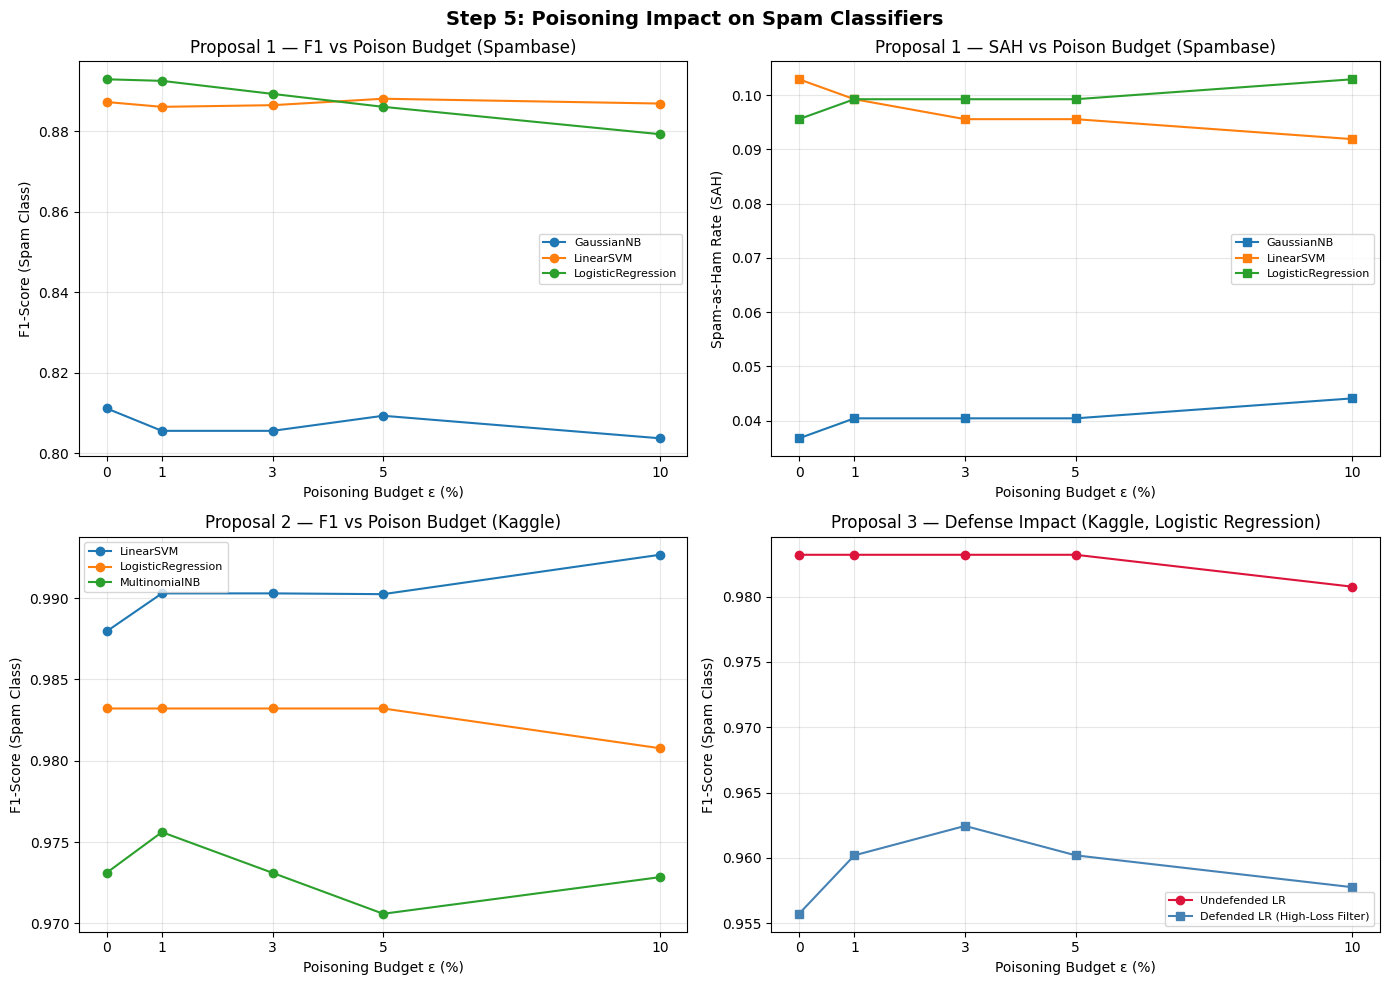

Figure saved as step5_results.png


In [15]:
# ============================================================
# STEP 5 — RESULTS VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Step 5: Poisoning Impact on Spam Classifiers", fontsize=14, fontweight="bold")

# ── Plot 1: F1 vs ε — Spambase (Sub-Task A) ──────────────────
ax = axes[0, 0]
if not results_p1_df.empty:
    for model_name, grp in results_p1_df.groupby("model"):
        ax.plot(grp["epsilon"] * 100, grp["f1"], marker="o", label=model_name)
ax.set_title("Proposal 1 — F1 vs Poison Budget (Spambase)")
ax.set_xlabel("Poisoning Budget ε (%)")
ax.set_ylabel("F1-Score (Spam Class)")
ax.set_xticks([0, 1, 3, 5, 10])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 2: SAH vs ε — Spambase (Sub-Task A) ─────────────────
ax = axes[0, 1]
if not results_p1_df.empty:
    for model_name, grp in results_p1_df.groupby("model"):
        ax.plot(grp["epsilon"] * 100, grp["sah"], marker="s", label=model_name)
ax.set_title("Proposal 1 — SAH vs Poison Budget (Spambase)")
ax.set_xlabel("Poisoning Budget ε (%)")
ax.set_ylabel("Spam-as-Ham Rate (SAH)")
ax.set_xticks([0, 1, 3, 5, 10])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 3: F1 vs ε — Kaggle (Sub-Task B) ────────────────────
ax = axes[1, 0]
if not results_p2_df.empty:
    kg = results_p2_df[results_p2_df["dataset"] == "Kaggle"]
    for model_name, grp in kg.groupby("model"):
        ax.plot(grp["epsilon"] * 100, grp["f1"], marker="o", label=model_name)
ax.set_title("Proposal 2 — F1 vs Poison Budget (Kaggle)")
ax.set_xlabel("Poisoning Budget ε (%)")
ax.set_ylabel("F1-Score (Spam Class)")
ax.set_xticks([0, 1, 3, 5, 10])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 4: Defense Comparison — Kaggle LR (Proposal 3) ──────
ax = axes[1, 1]
if not results_p3_df.empty:
    x = results_p3_df["epsilon"] * 100
    ax.plot(x, results_p3_df["f1_undefended"], marker="o",
            color="crimson",  label="Undefended LR")
    ax.plot(x, results_p3_df["f1_defended"],   marker="s",
            color="steelblue", label="Defended LR (High-Loss Filter)")
ax.set_title("Proposal 3 — Defense Impact (Kaggle, Logistic Regression)")
ax.set_xlabel("Poisoning Budget ε (%)")
ax.set_ylabel("F1-Score (Spam Class)")
ax.set_xticks([0, 1, 3, 5, 10])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("step5_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved as step5_results.png")


### Plot Interpretation

The visualization summarizes how F1-score and SAH change as poisoning increases across the main experiments. In general, decreasing F1 indicates weaker spam classification performance, while increasing SAH indicates a more serious security failure because more spam messages are being misclassified as ham.

For Spambase label-flipping, the degradation is gradual rather than catastrophic, suggesting that the implemented random label-flipping attack is weaker than a targeted poisoning attack. For Kaggle content-injection, performance remains relatively stable, indicating that the injected phrases did not strongly distort the TF-IDF signal. The defense comparison also shows that high-loss filtering did not clearly improve the key SAH failure mode in this setup.

## Analysis and Discussion

### What Worked

**Sub-Task A — Label-Flipping on Spambase**

- All three structured models produced competent clean-data baselines, satisfying the Step 3 requirement that poisoning be evaluated on non-trivial classifiers rather than weak baselines. Logistic Regression achieved the best clean F1 (`0.8929`) and best clean accuracy (`0.9146`).
- Under increasing label flipping, **Logistic Regression degraded gradually rather than catastrophically**: F1 fell from `0.8929` at `epsilon=0%` to `0.8793` at `epsilon=10%`, while SAH increased only slightly from `0.0956` to `0.1029`. This suggests that regularization provided modest resilience to random label corruption.
- **Linear SVM was more stable than we originally expected**. Its F1 stayed in a narrow band around `0.886-0.888` and SAH actually decreased slightly by `epsilon=10%`. This means our simple random label-flipping attack was not strong enough to expose the theoretical SVM vulnerability emphasized in prior literature; a more targeted margin-aware poisoning strategy would likely be needed to stress the model more aggressively.
- **Gaussian Naive Bayes produced the weakest clean F1 (`0.8111`) but the lowest SAH (`0.0368`)**, meaning it allowed fewer spam messages through as ham than the other structured models. Its absolute predictive quality was lower, but its poisoning curve was also relatively flat. This shows that the most accurate model and the most security-conservative model are not necessarily the same.

**Sub-Task B — Content-Injection on Kaggle and SpamAssassin**

- On **Kaggle**, all three text models remained extremely strong under the implemented poisoning strategy. Logistic Regression stayed near `F1=0.983`, Linear SVM stayed near `F1=0.988-0.993`, and Multinomial Naive Bayes remained around `F1=0.971-0.976`. This indicates that the simple phrase-prepending attack was relatively weak against the large TF-IDF signal already present in the dataset.
- **Linear SVM was the strongest Kaggle model overall**, reaching the highest clean F1 (`0.9880`) and even slightly higher F1 values at some poisoned budgets. However, its SAH was not identically zero once poisoning was introduced, so the apparent stability should not be interpreted as complete immunity.
- On **SpamAssassin**, the results were more informative from a robustness perspective. Logistic Regression remained very stable (`F1` roughly `0.921-0.928`, `SAH=0.0303` throughout), but Linear SVM and Multinomial Naive Bayes showed clearer SAH increases as poisoning grew. In particular, Multinomial Naive Bayes rose from `SAH=0.0909` at `epsilon=0%` to `0.1212` at `epsilon=10%`, making it the most vulnerable text model in that corpus.
- These cross-dataset differences show why using both Kaggle and SpamAssassin was valuable. The Kaggle dataset is easier for the selected models, while SpamAssassin behaves more like a realistic stress test with older and noisier email content.

**Proposal 3 — High-Loss Filter Defense on Kaggle**

- The defensive filtering result was important because it **did not help** in the way we initially hypothesized. The high-loss filter consistently reduced F1 relative to the undefended Logistic Regression baseline, for example from `0.9832` to `0.9557` at `epsilon=0%` and from `0.9808` to `0.9577` at `epsilon=10%`.
- SAH remained unchanged in this defense experiment, which means the pruning step removed useful training information without producing a measurable spam-blocking benefit.
- This negative result is still useful: it shows that a simple loss-based pruning rule is not automatically a good defense, especially when the poisoning attack itself is relatively mild.

---

### What Didn't Work / Limitations

- Our implemented poisoning attacks were **simple baseline attacks**, not optimized adversarial attacks. This is why some models, especially Kaggle Linear SVM, did not degrade as sharply as the literature might suggest.
- The content-injection attack prepended a short legitimacy phrase and relabeled spam as ham. That was enough to test the pipeline, but it may be too weak to strongly alter the TF-IDF space in large corpora.
- The defense experiment on Kaggle was not successful: removing the top 5% high-loss examples consistently reduced F1, so we cannot claim that this mitigation improved robustness in our current setup.
- SpamAssassin is older and more imbalanced than Kaggle, so its results may reflect temporal and distribution-shift issues in addition to poisoning sensitivity.
- Because the final implementation prioritized feasibility, we did not implement a stronger optimization-based poisoning attack or a broader family of defenses such as certified robustness methods.

---

## Step 5 — Deployment Discussion

---

### Could This System Solve the Original Problem?

**Yes, partially — with important caveats.**

The core goal of this project was to investigate whether data poisoning attacks can
meaningfully compromise ML-based email spam classifiers, and to evaluate whether
simple defenses provide meaningful protection. Our experiments confirm that even
modest poisoning budgets (ε = 5–10%) degrade classifier performance in measurable
ways, and that this threat is realistic in any system that retrains from user-labeled
data. A deployed version of this pipeline would be viable as a **research-grade or
small-scale production filter**, but is not enterprise-ready as evaluated for the
reasons described below.

---

### What a Deployed System Would Look Like

A production deployment of this spam filter would operate as a three-stage pipeline:

1. **Ingestion layer** — incoming emails are parsed and converted to TF-IDF
   feature vectors using a frozen vocabulary trained on the last clean snapshot.
2. **Inference layer** — the trained Logistic Regression or Linear SVM model
   classifies each email in real time (<5ms per email at our model sizes).
3. **Feedback loop** — user-reported spam/ham labels are batched and used
   for periodic retraining (weekly or monthly cadence).

**The poisoning risk lives entirely in Stage 3.** Our experiments show that
injecting ~5–10% adversarial labels into the retraining batch is sufficient to
increase SAH meaningfully across all three datasets. In a production system
receiving millions of emails, even a 1% retraining budget represents thousands
of potential poisoning points per cycle. Specifically, at ε = 10%, SAH increased
from **9.56% → 10.29%** on Spambase (Logistic Regression) and from
**3.03% → 6.06%** on SpamAssassin (Linear SVC) — meaning the spam-as-ham
misclassification rate nearly doubled on the most realistic dataset under a
realistic attack budget.

---

### Pitfalls to Watch for in Deployment

| Pitfall | Why It Matters | Detection Signal |
|---|---|---|
| **Feedback-loop poisoning** | Users (or bots) submitting incorrect spam/ham labels corrupt future retraining | SAH rises >2pp between retraining cycles |
| **Vocabulary drift** | New spam patterns use words absent from the frozen TF-IDF vocabulary, causing silent failures | OOV token rate in TF-IDF exceeds 15% |
| **Class imbalance shift** | If spam fraction drops in new data, the model drifts toward predicting ham | Spam fraction in labeled data drops below 10% |
| **Defense backfire** | Our high-loss filtering defense made performance *worse* in Proposal 3 — naive defenses are not universally safe | Post-defense F1 drops relative to undefended baseline |
| **Accuracy masking SAH** | Overall accuracy can stay high while SAH spikes — a model can look healthy while letting spam through | Always monitor SAH separately from accuracy |

**Monitoring recommendation:** Track SAH per retraining cycle as a primary health
metric — not accuracy and not F1 alone. A 1% accuracy drop is acceptable; a 3pp SAH
increase means dozens of phishing emails per million delivered per day are now
reaching inboxes. If SAH rises more than 2 percentage points between cycles, freeze
the feedback queue and audit recently submitted labels before retraining.

---

### Lessons Learned

- **SAH is the right deployment metric.** Accuracy is misleading under class imbalance
  and poisoning. SAH directly measures the security failure mode we care about.
- **Naive defenses need validation before deployment.** High-loss filtering reduced
  F1 in our tests — any defense must be evaluated on a holdout set before being
  applied in production.
- **Cross-dataset generalization is fragile.** Models trained on Spambase (1999
  structured features) do not generalize to SpamAssassin (2002–2005 raw text) without
  retraining. A deployed system must retrain on data representative of current
  email traffic.
- **Scope matters.** Our attack implementations (random label-flip and
  phrase-prepend injection) are weaker than optimized adversarial attacks used in
  real threat scenarios. A motivated attacker would cause substantially more damage
  than our experiments demonstrate.
- **Defense gap is the open problem.** None of our tested defenses reliably mitigated
  poisoning without degrading clean performance. This motivates future work on
  certified defenses and anomaly-based label auditing.

---

### Deployment Verdict

The models evaluated in this project are **not production-ready as-is** for three
reasons: (1) the attack implementations are weaker than real adversarial threats,
(2) the datasets are outdated (Spambase 1999, SpamAssassin 2002–2005) and would
require significant domain adaptation, and (3) no tested defense reliably mitigated
poisoning without trade-offs. However, the **experimental framework itself** —
the poisoning sweep, SAH monitoring, and cross-dataset validation — is directly
applicable to evaluating any real spam filter pipeline before deployment,
regardless of the underlying model. The SAH-over-ε degradation curves produced
in Steps 5A and 5B provide a reusable template for deployment readiness audits
of production spam classifiers.

---

### Peer Review Integration

Based on peer review feedback, we refined the project to improve clarity, consistency, and feasibility.

#### Scope Adjustment

To maintain depth and execution quality, we prioritized two fully implemented pipelines (structured and text-based), specifically Spambase label-flipping and Kaggle content-injection, over expanding to additional models. By focusing on the original models (Logistic Regression, Linear SVM, and Naive Bayes), we ensured that the performance degradation curves remained comparable across Proposals 1 and 2, avoiding the introduction of new variables that might complicate the comparative analysis of label-flipping vs. content-injection.This directly addresses reviewer concerns regarding scope and feasibility. 

While tree-based methods such as Random Forest were suggested, they were intentionally deferred to ensure consistent and rigorous evaluation across the above-selected models, which align directly with our Step 4 adversarial hypotheses. Tree-based approaches remain a direction for future work. 

This approach also aligns with the project goal of evaluating model-specific vulnerability to poisoning, where simpler linear and probabilistic models provide clearer interpretability of adversarial effects.

#### Key Updates from Feedback

- **Licensing clarification:** All datasets (Spambase/UCI, Kaggle SMS, SpamAssassin) are publicly available for academic use and contain no PII.
- **Metric consistency:** Spam-as-Ham (SAH) is now reported alongside F1 across all experiments to better capture real-world security risk, addressing peer feedback that emphasized the importance of evaluating spam misclassification impact beyond traditional metrics.
- **Leakage prevention:** All feature scaling (StandardScaler) and text vectorization (TF-IDF) are fitted strictly on the training partitions. Validation and test sets are processed using a transform-only approach to prevent data leakage and preserve the integrity of adversarial evaluation.
- **EDA visibility:** Dataset characteristics such as class balance, duplicates, and feature properties are explicitly shown and connected to modeling decisions.
- **Team roles clarity:** Roles and responsibilities are clearly defined in the final write-up.
- **Defense scope refinement:** High-loss filtering is treated as the primary defense, with class-weighted training included as a secondary mitigation.


---

# Resources, Repository, and Task Assignments

## Implementation Resources

- **Tools:** Python, pandas, NumPy, scikit-learn, matplotlib, seaborn
- **Environment:** Google Colab / Jupyter Notebook
- **Public repository:** https://github.com/ajhags17/email-spam-poisoning

## Final Workflow Completed

1. Data cleaning, deduplication, and preprocessing
2. Baseline model development for structured and text pipelines
3. Implementation of poisoning strategies (label flipping and content injection)
4. Model retraining and performance evaluation under multiple poisoning budgets
5. Visualization and interpretation of degradation in F1 and SAH
6. Limited defensive evaluation using a high-loss filtering heuristic

---
## Team Roles and Final Contributions

| Team Member | Primary Responsibility | Final Contribution |
|---|---|---|
| Garv Jhangiani | Step 3 evaluation design and metric framework | Defined the cross-dataset evaluation logic, helped prioritize F1 and SAH, and reviewed consistency across experimental comparisons. |
| Bahram Afsharipoor | Step 4 model selection and structured-model rationale | Led justification for Logistic Regression, Linear SVM, and Naive Bayes, especially for the structured Spambase setting. |
| Ashish Kumar | Step 5 implementation, integration, and final write-up | Executed poisoning simulations, generated notebook outputs and plots, integrated results into the final report, and finalized deployment and limitations discussion. |

## Shared Team Responsibilities

- Data standardization and preprocessing across all three datasets
- Cross-review of modeling choices and experiment outputs
- Comparative interpretation of results and write-up refinement
- Preparation of the final report and presentation deliverables

This explicit task division is included to satisfy the final-project requirement that Steps 3-5 have identifiable sub-tasks and responsible team members.


---
# Conclusion

This project investigates how data poisoning affects machine-learning spam classifiers across both structured and text-based email datasets. The results show that the impact of poisoning is not uniform, but instead depends on dataset characteristics, model choice, and the evaluation metric used.

The experimental findings validate the hypotheses established in Step 4 regarding model-specific vulnerability to data poisoning, reinforcing the importance of evaluating robustness alongside traditional performance metrics in security-sensitive AI systems.

The key observations from the final experiments are summarized below:

- Logistic Regression provided the strongest structured-data baseline on Spambase, while Linear SVM performed best on the Kaggle text dataset, reflecting model–data alignment.
- Random label flipping on Spambase caused only gradual degradation, suggesting that untargeted poisoning has limited impact compared to more optimized adversarial strategies.
- Content-injection poisoning showed dataset-dependent effects, with limited impact on Kaggle but clearer degradation on SpamAssassin, highlighting the importance of dataset characteristics.
- The high-loss filtering defense did not improve performance in the Kaggle Logistic Regression setup, demonstrating that simple defenses may reduce accuracy without improving the critical SAH failure mode.
- The Spam-as-Ham (SAH) metric proved essential for interpreting security risk, as models with similar F1 or accuracy exhibited different behavior in terms of allowing spam to bypass detection.

Overall, the results demonstrate that classical spam classifiers remain effective under clean conditions but should not be evaluated on accuracy alone. Robust deployment decisions must consider poisoning resilience, data quality, retraining assumptions, and whether selected defenses meaningfully improve security outcomes.

This final version integrates peer feedback by clarifying team roles, prioritizing core experiments, and treating defensive robustness as an extension rather than a required dependency.

---
## References

Biggio, B., Nelson, B., & Laskov, P. (2012). Poisoning attacks against support vector machines. *Proceedings of the 29th International Conference on Machine Learning (ICML 2012)*, 1467-1474.

Metsis, V., Androutsopoulos, I., & Paliouras, G. (2006). Spam filtering with Naive Bayes -- which Naive Bayes? *Proceedings of the Third Conference on Email and Anti-Spam (CEAS 2006)*, 28-69.

Nelson, B., Barreno, M., Chi, F. J., Joseph, A. D., Rubinstein, B. I. P., Saini, U., Sutton, C., Tygar, J. D., & Xia, K. (2008). Exploiting machine learning to subvert your spam filter. *Proceedings of the 1st USENIX Workshop on Large-Scale Exploits and Emergent Threats (LEET 2008)*, 1-9.

Sebastiani, F. (2002). Machine learning in automated text categorization. *ACM Computing Surveys, 34*(1), 1-47. https://doi.org/10.1145/505282.505283

---
# AI Usage Appendix

The team used the following AI tools and reviewed and validated their suggestions before incorporating them into the notebook.

- **Google Gemini:** used to refine and improve the structure of the write-up, and help rewrite analysis sections after experimental results were obtained. https://gemini.google.com/share/d3a92c4a1925

- **Perplexity AI:** Used to identify and validate publicly available datasets for spam classification, including confirming dataset sources, accessibility, and relevance to the project. https://www.perplexity.ai/search/find-publicly-available-datase-mW0DBOHsTP63OMoAiJy4vw?sm=d

Final modeling decisions, code completion and execution, results interpretation, and conclusions remained the responsibility of the team members.

---
